In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from decimal import Decimal
import itertools
import csv
import seaborn as sns
import requests
import re
import ast

In [3]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('loglog.png')
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def pearson(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = pearsonr(data1, data2)
    formatted_p_value = '{:e}'.format(p_value)
    return correlation, formatted_p_value

def get_reactions_for_compound(compound_id):
    response = requests.get(f'https://rest.kegg.jp/link/reaction/{compound_id}')
    lines = response.text.split('\n')
    
    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    return reactions

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX

In [37]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
x2foAveALL = csv2dict('../data/assets/xgroup2/xgroup2foAveALL.csv')
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)

x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')
x2modules = csv2dict('../data/assets/xgroup2/xgroup2modules.csv')
x2maps = csv2dict('../data/assets/xgroup2/xgroup2maps.csv')
x2arc = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')
x2class = csv2dict('../data/assets/xgroup2/xgroup2class.csv')

module2name = csv2dict('../data/assets/module2name.csv')
module2rns = csv2dict('../data/assets/module2rns.csv')
map2name = csv2dict('../data/assets/map2name.csv')

rn2name = csv2dict('../data/assets/rn2name.csv')
rn2def = csv2dict('../data/assets/rn2def_complete.csv')
rn2def_SI = csv2dict('../data/assets/rn2def_versions.csv')
rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2cpd_SI = csv2dict('../data/assets/rn2cpds_SI.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

rn2ko = csv2dict('../data/assets/rn2ko.csv')
ko2name = csv2dict('../data/assets/ko2name.csv')

cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
cpd2rn = csv2dict('../data/assets/cpd2rn.csv')
    
print(len(x2foAveNONE))
print(len(x2foAveALL))
print(len(x2ns))
print(len(x2rn))
print('')
print(len(x2name))
print(len(x2modules))
print(len(x2maps))
print(len(x2arc))
print(len(x2class))
print('')
print(len(rn2rules))
print(len(module2name))
print(len(module2rns))
print(len(map2name))

397
397
396
396

237
274
370
2458
2458

12872
479
479
569


In [5]:
for rn in x2rn['2006']:
    print(rn, rn2rules[rn])

R01771 {frozenset({'212'}), frozenset({'206'}), frozenset({'2006'})}
R00582 {frozenset({'2006'}), frozenset({'7525'})}
R00551 {frozenset({'2006'})}
R07394 {frozenset({'2006'})}
R07392 {frozenset({'281', '2006'}), frozenset({'281'})}
R07395 {frozenset({'281', '2006'}), frozenset({'2006'})}
R02285 {frozenset({'2006'})}
R03350 {frozenset({'2006'})}
R05647 {frozenset({'2006'})}
R00851 {frozenset({'2006'}), frozenset({'7558'})}
R00549 {frozenset({'1', '2006'}), frozenset({'2005', '1'}), frozenset({'1'})}
R07280 {frozenset({'208'}), frozenset({'2006'})}
R01157 {frozenset({'2006'})}
R05357 {frozenset({'2006'})}
R10466 {frozenset({'2006'})}
R11240 {frozenset({'2006'})}
R10547 {frozenset({'2006'})}
R01334 {frozenset({'2006'})}
R03013 {frozenset({'4018', '7587'}), frozenset({'212', '2006'}), frozenset({'2002'})}
R03457 {frozenset({'212'}), frozenset({'212', '2006'})}
R07110 {frozenset({'7579', '2006'})}
R11440 {frozenset({'2006'})}
R10748 {frozenset({'2006'})}
R07109 {frozenset({'7579', '2006'})

In [6]:
# DS average
xgroup2ds_a = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv')
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv')
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv')
print(len(xgroup2ds_e))

2230
2230
2230


### O2

In [7]:
O2rnsKEGG = get_reactions_for_compound('C00007')

In [8]:
with open('../data/assets/reaction_iteration_O2_ablation.csv', 'r') as csv_file:
    csv_reader = csv.reader(csv_file)
    
    # Skip the header row
    next(csv_reader)
    
    rns_unreached_wo_O2 = []
    for row in csv_reader:
        if '' in row:
            if row[0][-2] != 'v':  # exclude reactions with "v"
                if row[0].startswith('R0') or row[0].startswith('R1'):
                    rns_unreached_wo_O2.append(row[0])
                else:
                    print(row[0])
            else:
                if row[0].endswith('v1'):  # rescue 'v1' because this file does not have "original" w/o version num
                    rns_unreached_wo_O2.append(row[0][:-3])

RZ_154
RZ_413
QUIN_SYN2
RZ_199
RZ_205
RZ_245
RZ_179
RZ_172
RZ_185
RZ_414
RZ_207
RZ_195
RZ_255
RZ_177
RZ_368
RZ_184
RZ_198
RZ_415
RZ_504
RZ_362
RZ_160
RZ_193
RZ_212
RZ_408
RZ_234
QUIN_SYN1
RZ_396
RZ_153
RZ_412
RZ_166
RZ_189
RZ_121
RZ_155
RZ_358
RZ_183
RZ_409
RZ_242
RZ_214
C11904_syn
RZ_208
RZ_170
C11903_syn
RZ_366
RZ_458
RZ_391
RZ_386
RZ_457


In [9]:
O2_direct_rn = set(rns_unreached_wo_O2) & set(O2rnsKEGG)
O2_indirect_rn = set(rns_unreached_wo_O2) - set(O2rnsKEGG)
len(O2_direct_rn), len(O2_indirect_rn), len(set(rns_unreached_wo_O2))

(753, 712, 1465)

In [10]:
# get the ratio
x2O2rn = {}
for x, rns in x2rn.items():
    fracdict = {'direct':[], 'indirect':[], 'total':[]}
    for rn in rns:
        if rn in O2_direct_rn:
            fracdict['direct'].append(rn)
        if rn in O2_indirect_rn:
            fracdict['indirect'].append(rn)
        if rn[:6] not in fracdict['total']:
            if rn.startswith('R0') or rn.startswith('R1'):
                fracdict['total'].append(rn)
    x2O2rn[x] = fracdict

In [11]:
a_only = {'5103'}
b_only = {'4036', '4035', '914', '3018', '582', '6051', '3339', '4054', '640', '6113', '1055', '3847', '6174'}
e_only = {'3322', '3257', '558', '3777', '3371'}
first10 = {'325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952'}
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}
aux = {'3323', '806', '197', '3686', '3692', '4046', '7578', '7536', '7546', '7572', '3304', '3257', '3018', '525', '4081', '873', '66', '3687', '4033', '4029', '914', '196', '4076', '4024', '3456', '7500', '218', '3697', '3960', '387', '3752', '632', '3699', '7587', '7604', '275', '3264', '4028', '4011', '7540', '1077', '7518', '3994', '3777', '4971', '3292', '7', '4', '258', '3691', '214', '1114', '3843', '557', '279', '6051', '3117', '64', '3281', '1143', '3847', '148', '1144', '2496', '177', '6058', '253', '3858', '4017', '558', '2493', '3001', '187', '4004', '581', '7568', '3374', '296', '3052', '4018', '103', '3685', '4025', '872', '4952', '4223', '5067', '313', '7602', '376', '4048', '4262', '4335', '3500', '865', '3115', '7563', '4044', '147', '7521', '3892', '6166', '6174', '4036', '5100', '4035', '4022', '640', '3269', '7522', '3339', '602', '3294', '6096', '192', '169', '3599', '75', '228', '3688', '805', '179', '3623', '3651', '6113', '603', '4159', '6075', '7601', '623', '6094', '7554', '4178', '189', '3005', '3993', '4002', '2008', '284', '1137', '5103', '881', '702', '4294', '4272', '3322', '7556', '1055', '503', '377', '7595', '629', '270', '144', '4020', '199', '102', '4054', '4045', '7507', '4953', '920', '184', '3997', '277', '154', '69', '611', '4161', '1074', '1001', '355', '3579', '4995', '378', '3321', '3654', '3794', '812', '4049', '106', '7544', '590', '268'}
arua = {'1055', '136', '158', '185', '199', '2010', '239', '270', '3001', '3052', '309', '3115', '319', '3688', '374', '3754', '3896', '4004', '4019', '4022', '4028', '4048', '4076', '4110', '4126', '4160', '4237', '4295', '5084', '528', '582', '590', '6051', '6096', '640', '7513', '7551', '7553', '7567', '842', '869', '875', '876', '9'}
forgotten = {'307', '4279', '4046', '3371', '7556', '4114', '3847', '6174', '1144', '144', '324', '196', '3076', '4024', '3960', '3752', '285', '581', '7568', '3374', '228', '7540', '73', '911', '6075', '7589', '106'}

def getXinfo(x):
    group = 'grp2'
    indepOrAux = 'indep'
    aruaX = ''
    only = ''
    mapping = ''
    
    if x in group1:
        group = 'grp1'
    if x in first10:
        group = 'first10'
    if x in aux:
        indepOrAux = 'aux'
    if x in arua:
        aruaX = ' |arua'
    if x in a_only:
        only = ' |a_only'
    if x in b_only:
        only = ' |b_only'
    if x in e_only:
        only = ' |e_only'
    if x in forgotten:
        mapping = ' |forgotten'
    
    
    print(f'X{x} |ds_a/b/e= {round(xgroup2ds_a[x], 2)} {round(xgroup2ds_b[x], 2)} {round(xgroup2ds_e[x], 2)} |fo={round(x2foAveNONE[x],1)} |ns={int(x2ns[x])} |#rn={len(x2rn[x])} |{group} |{indepOrAux} |Xname={x2name.get(x, "N/A")}{aruaX}{only}{mapping}')

In [12]:
def getXinfo2(x):
    if x2modules.get(x, 0) != 0:
        print(f'      |{next(iter(x2modules[x]))}: {module2name[next(iter(x2modules[x]))]} |O2={len(x2O2rn[x]["direct"])}:{len(x2O2rn[x]["indirect"])}/{len(x2O2rn[x]["total"])} |{x2arc[x]}')
    else:
        if x2maps.get(x, 0) != 0:
            print(f'      |{next(iter(x2maps[x]))}: {map2name[next(iter(x2maps[x]))]}|O2={len(x2O2rn[x]["direct"])}:{len(x2O2rn[x]["indirect"])}/{len(x2O2rn[x]["total"])} |{x2arc[x]}')
        else:
            print(f'      |no module, no map                                                |O2={len(x2O2rn[x]["direct"])}:{len(x2O2rn[x]["indirect"])}/{len(x2O2rn[x]["total"])} |{x2arc[x]}')

# What's up with the triplet anyway?

In [24]:
fixed = pd.read_pickle('../runs/2024-06-17_19-39-53_check_pull-request.pkl.gz')

In [31]:
fixed.folds_cumiter['602'], fixed.folds_cumiter['4952'], fixed.folds_cumiter['4953']

(188, 188, 189)

In [25]:
fixed.cpds_cumiter['C00002']

195

In [56]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 195:
        if 'C00002' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R00578 C00020 + C00013 + C00152 + C00025 => C00002 + C00049 + C00064 + C00001 {frozenset({'2005'})}
R00206_v1 C00020 + C00074 + C00013 + Z00029 => C00002 + C00022 + C00009 + Z00029 {frozenset({'206', '2487', '2002'})}
R00199_v2 C00020 + C00074 + C00009 + Z00029 => C00002 + C00022 + C00001 + Z00029 {frozenset({'2487', '2002'})}
R00199_v1 C00020 + C00074 + C00009 + Z00030 => C00002 + C00022 + C00001 + Z00030 {frozenset({'2487', '2002'})}
R01049_v1 C00020 + C00119 + Z00029 => C00002 + C00117 + Z00029 {frozenset({'7573'})}

0 C00022 Pyruvate
33 C00064 L-Glutamine
0 Z00029 Mg
3 C00074 Phosphoenolpyruvate
0 C00009 Orthophosphate
195 C00002 ATP
55 C00119 5-Phospho-alpha-D-ribose 1-diphosphate
0 Z00030 Mn
0 C00025 L-Glutamate
30 C00117 D-Ribose 5-phosphate
0 C00049 L-Aspartate
0 C00001 H2O
4 C00013 Diphosphate
194 C00020 AMP
20 C00152 L-Asparagine


In [57]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 194:
        if 'C00020' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R00190_v1 C00147 + C00119 + Z00029 => C00020 + C00013 + Z00029 {frozenset({'7573'})}
R00183_v1 C00212 + C00009 + Z00054 => C00020 + C00001 + Z00054 {frozenset({'246', '805'}), frozenset({'7527'}), frozenset({'2006'})}
R00183_v4 C00212 + C00009 + Z00030 => C00020 + C00001 + Z00030 {frozenset({'246', '805'}), frozenset({'7527'}), frozenset({'2006'})}
R00183_v3 C00212 + C00009 + Z00069 => C00020 + C00001 + Z00069 {frozenset({'246', '805'}), frozenset({'7527'}), frozenset({'2006'})}
R00183_v5 C00212 + C00009 + Z00029 => C00020 + C00001 + Z00029 {frozenset({'246', '805'}), frozenset({'7527'}), frozenset({'2006'})}
R00183_v2 C00212 + C00009 + Z00006 => C00020 + C00001 + Z00006 {frozenset({'246', '805'}), frozenset({'7527'}), frozenset({'2006'})}
R00182 C00147 + C00117 => C00020 + C00001 {frozenset({'2011'}), frozenset({'7563', '3623'})}

0 Z00069 Divalent Metal (M2)
0 Z00029 Mg
0 Z00006 Cobalt
193 C00147 Adenine
0 C00009 Orthophosphate
0 Z00030 Mn
0 Z00054 Zinc
30 C00117 D-Ribose 5-phosphate

In [ ]:
# 193 C00147 Adenine
# 193 C00212 Adenosine

In [58]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 193:
        if 'C00147' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R01244_v2 C00262 + C00014 + Z00054 => C00147 + C00001 + Z00054 {frozenset({'2002', '3292'}), frozenset({'2002'})}
R01244_v1 C00262 + C00014 + Z00030 => C00147 + C00001 + Z00030 {frozenset({'2002', '3292'}), frozenset({'2002'})}

192 C00262 Hypoxanthine
193 C00147 Adenine
0 Z00030 Mn
0 C00014 Ammonia
0 Z00054 Zinc
0 C00001 H2O


In [ ]:
# 192 C00262 Hypoxanthine
# 192 C00294 Inosine

In [59]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 192:
        if 'C00294' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R01126_v4 C00294 + C00009 + Z00069 + C00294 + C00009 + Z00030 => C00130 + C00001 + Z00069 + C00130 + C00001 + Z00030 {frozenset({'246', '805'}), frozenset({'2007', '10'}), frozenset({'7527'}), frozenset({'2006'})}
R01126_v1 C00294 + C00009 + Z00006 + C00294 + C00009 + Z00054 => C00130 + C00001 + Z00006 + C00130 + C00001 + Z00054 {frozenset({'246', '805'}), frozenset({'2007', '10'}), frozenset({'7527'}), frozenset({'2006'})}
R01126_v2 C00294 + C00009 + Z00030 + C00294 + C00009 + Z00006 => C00130 + C00001 + Z00030 + C00130 + C00001 + Z00006 {frozenset({'246', '805'}), frozenset({'2007', '10'}), frozenset({'7527'}), frozenset({'2006'})}
R01126_v5 C00294 + C00009 + Z00029 => C00130 + C00001 + Z00029 {frozenset({'246', '805'}), frozenset({'2007', '10'}), frozenset({'7527'}), frozenset({'2006'})}
R01126_v3 C00294 + C00009 + Z00029 + C00294 + C00009 + Z00069 => C00130 + C00001 + Z00029 + C00130 + C00001 + Z00069 {frozenset({'246', '805'}), frozenset({'2007', '10'}), frozenset({'7527'}), froze

In [ ]:
# 191 C00130 IMP
# 191 C00130 IMP

In [60]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 191:
        if 'C00130' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R01127 C04734 => C00130 + C00001 {frozenset({'2492', '7543'}), frozenset({'210'})}

0 C00001 H2O
191 C00130 IMP
190 C04734 1-(5'-Phosphoribosyl)-5-formamido-4-imidazolecarboxamide


In [61]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 190:
        if 'C04734' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R06975_gATP_v1 C00009 + C04734 + C00009 + Z00030 => C00058 + C04677 + C00013 + Z00030 {frozenset({'2003', '206'})}

0 C00009 Orthophosphate
0 Z00030 Mn
189 C04677 1-(5'-Phosphoribosyl)-5-amino-4-imidazolecarboxamide
0 C00058 Formate
190 C04734 1-(5'-Phosphoribosyl)-5-formamido-4-imidazolecarboxamide
4 C00013 Diphosphate


In [62]:
cs = set()
for rn, i in fixed.rns_cumiter.items():
    if i == 189:
        if 'C04677' in rn2eqn_SI[rn]:
            print(rn, rn2eqn_SI[rn], rn2rules[rn])
            for c in rn2cpd_SI[rn]:
                cs.add(c)
print('')
for c in cs:
    print(fixed.cpds_cumiter[c], c, cpd2name[c])

R04559 C00122 + C04677 => C04823 {frozenset({'602', '4952', '4953'})}

86 C04823 1-(5'-Phosphoribosyl)-5-amino-4-(N-succinocarboxamide)-imidazole
0 C00122 Fumarate
189 C04677 1-(5'-Phosphoribosyl)-5-amino-4-imidazolecarboxamide


# abs req & uniq asso... are they O2-dependent?

In [13]:
for x in arua:
    getXinfo(x)
#     getXinfo2(x)

X3001 |ds_a/b/e= 0.03 0.08 0.05 |fo=239.4 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |arua
X3754 |ds_a/b/e= 0.74 0.97 0.85 |fo=161.1 |ns=4309 |#rn=14 |grp2 |indep |Xname=N/A |arua
X4019 |ds_a/b/e= 0.11 0.72 0.88 |fo=137.8 |ns=4313 |#rn=15 |grp2 |indep |Xname=N/A |arua
X4028 |ds_a/b/e= 0.05 0.14 0.62 |fo=358.5 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |arua
X528 |ds_a/b/e= 0.17 0.35 0.72 |fo=256.6 |ns=4314 |#rn=7 |grp2 |indep |Xname=N/A |arua
X374 |ds_a/b/e= 0.0 0.01 0.02 |fo=294.6 |ns=4315 |#rn=5 |grp2 |indep |Xname=N/A |arua
X6096 |ds_a/b/e= 0.0 0.05 0.02 |fo=239.5 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |arua
X4022 |ds_a/b/e= 0.09 0.34 0.47 |fo=239.1 |ns=4314 |#rn=2 |grp2 |aux |Xname=N/A |arua
X590 |ds_a/b/e= 0.02 0.09 0.64 |fo=223.9 |ns=4313 |#rn=11 |grp2 |aux |Xname=N/A |arua
X4110 |ds_a/b/e= 0.0 0.04 0.47 |fo=324.4 |ns=4315 |#rn=4 |grp2 |indep |Xname=N/A |arua
X5084 |ds_a/b/e= 0.01 0.9 0.93 |fo=143.1 |ns=4315 |#rn=37 |grp2 |indep |Xname=Outer membrane meander beta-barrels |arua
X876 |ds_a/b/

In [14]:
print('timing   X    direct%  indirect%')
print('----------------------------------')
for x in arua:
    if x2foAveNONE[x] < x2foAveNONE['3997']:
        timing = 'before'
    else:
        timing = 'AFTER '
    print(f'{timing}: X{x}   {round(len(x2O2rn[x]["direct"])/len(x2O2rn[x]["total"]), 2)}      {round(len(x2O2rn[x]["indirect"])/len(x2O2rn[x]["total"]), 2)}     {module2name[next(iter(x2modules[x]))]}')

timing   X    direct%  indirect%
----------------------------------
before: X3001   0.0      0.0     Lysine biosynthesis, succinyl-DAP pathway, aspartate => lysine
before: X3754   0.0      0.0     N-glycan precursor biosynthesis
before: X4019   0.0      0.09     Lovastatin biosynthesis, malonyl-CoA => lovastatin acid
AFTER : X4028   0.33      0.0     Photorespiration
before: X528   0.0      0.0     N-glycan precursor biosynthesis
before: X374   0.0      0.0     Toluene degradation, anaerobic, toluene => benzoyl-CoA
before: X6096   0.0      0.0     Pyridoxal-P biosynthesis, erythrose-4P => pyridoxal-P
before: X4022   0.0      0.0     Histidine degradation, histidine => N-formiminoglutamate => glutamate
before: X590   0.0      0.0     Formaldehyde assimilation, xylulose monophosphate pathway
AFTER : X4110   0.5      0.0     Purine degradation, xanthine => urea
before: X5084   0.0      0.13     KDO2-lipid A modification pathway
before: X876   0.0      0.0     Staphyloferrin B biosynthesis

In [30]:
getXinfo('253')
getXinfo2('253')

X253 |ds_a/b/e= 0.41 0.67 0.66 |fo=238.1 |ns=3063 |#rn=1 |grp1 |aux |Xname=N/A
      |M00845: Arginine biosynthesis, glutamate => acetylcitrulline => arginine |O2=0:0/1 |a+b complex topology


In [36]:
x2rn['253']

['R01954']

In [39]:
rn2rules['R01086']

{frozenset({'4953', '602'}), frozenset({'213', '4953', '602'})}

In [31]:
getXinfo('7544')
getXinfo2('7544')

X7544 |ds_a/b/e= 0.72 0.84 0.64 |fo=277.7 |ns=3069 |#rn=21 |grp1 |aux |Xname=N/A
      |M00023: Tryptophan biosynthesis, chorismate => tryptophan |O2=0:0/13 |a/b three-layered sandwiches


In [32]:
getXinfo('875')
getXinfo2('875')

X875 |ds_a/b/e= 0.4 0.7 0.61 |fo=235.8 |ns=2855 |#rn=2 |grp1 |indep |Xname=N/A |arua
      |M00022: Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate |O2=0:0/1 |a+b two layers


In [35]:
# biotin

getXinfo('7584')
getXinfo2('7584')

X7584 |ds_a/b/e= 0.51 0.89 1.0 |fo=228.0 |ns=3275 |#rn=164 |grp1 |indep |Xname=N/A
      |M00113: Jasmonic acid biosynthesis |O2=0:4/121 |a/b three-layered sandwiches


# checking interesting outliers

In [15]:
getXinfo('1')

X1 |ds_a/b/e= 1.0 1.0 1.0 |fo=3.0 |ns=2268 |#rn=492 |grp1 |indep |Xname=cradle loop barrel


## fold that Josh pointed out:

In [16]:
x2O2rnFracDirect = {}
for x, d in x2O2rn.items():
    x2O2rnFracDirect[x] = len(d['direct']) / len(d['total'])
    
x2O2rnFracIndirect = {}
for x, d in x2O2rn.items():
    x2O2rnFracIndirect[x] = len(d['indirect']) / len(d['total'])

In [17]:
x2O2rnFrac = {}
for x, d in x2O2rn.items():
    x2O2rnFrac[x] = len((set(d['direct']) | set(d['indirect']))) / len(d['total'])

In [18]:
for x in x2O2rnFracIndirect.keys():
    if x2O2rnFracIndirect[x] > 0.4:
        if x2foAveNONE[x] < 100:
            print(x, x2name.get(x, 'NO NAME'), x2O2rnFracIndirect[x], x2foAveNONE[x])
            for mod in x2modules[x]:
                print(mod, module2name[mod])

7561 NO NAME 0.5 57.338
M00939 Pyrimidine degradation, uracil => 3-hydroxypropanoate
M00622 Nicotinate degradation, nicotinate => fumarate
M00835 Pyocyanine biosynthesis, chorismate => pyocyanine


## dip at iter# = 98 (NONE)

In [19]:
for x in {'108', '4178', '355'}:
    getXinfo(x)
    if x2modules.get(x, 'NO MODULE') != 'NO MODULE':
        for mod in x2modules.get(x, 'NO MODULE'):
            print(mod, module2name[mod])
    else:
        print('NO MODULE')
        for mp in x2maps[x]:
            print(mp, map2name[mp])
        
    print('----------')

X108 |ds_a/b/e= 0.08 0.07 1.0 |fo=98.5 |ns=4294 |#rn=59 |grp2 |indep |Xname=EF-hand
M00130 Inositol phosphate metabolism, PI=> PIP2 => Ins(1,4,5)P3 => Ins(1,3,4,5)P4
M00053 Deoxyribonucleotide biosynthesis, ADP/GDP/CDP/UDP => dATP/dGTP/dCTP/dUTP
----------
X355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rn=19 |grp2 |aux |Xname=N/A
NO MODULE
map00500 Starch and sucrose metabolism
map00052 Galactose metabolism
----------
X4178 |ds_a/b/e= 0.02 0.12 0.92 |fo=97.5 |ns=4315 |#rn=21 |grp2 |aux |Xname=N/A
M00073 N-glycan precursor trimming
M00074 N-glycan biosynthesis, high-mannose type
----------


In [20]:
for rn in module2rns['M00053']:
    print(rn, rn2rules[rn])

R02017 {frozenset({'103', '1074', '150', '2500'}), frozenset({'150', '1074', '2500', '102', '103', '108'})}
R01137 {frozenset({'304'})}
R02019 {frozenset({'103', '1074', '150', '2500'}), frozenset({'150', '1074', '2500', '102', '103', '108'})}
R01857 {frozenset({'304'})}
R02024 {frozenset({'103', '1074', '150', '2500'}), frozenset({'150', '1074', '2500', '102', '103', '108'})}
R02326 {frozenset({'304'})}
R02018 {frozenset({'103', '1074', '150', '2500'})}
R02331 {frozenset({'304'})}


In [21]:
for rn in module2rns['M00130']:
    print(rn, rn2rules[rn])

R03361 {frozenset({'206'}), frozenset({'206', '109'})}
R03469 {frozenset({'206'})}
R03435 {frozenset({'4', '11', '214', '220'}), frozenset({'2002', '108', '11', '220'}), frozenset({'2002', '108', '11'}), frozenset({'4', '11', '214'}), frozenset({'2002', '11', '221'})}
R03433 {frozenset({'206'})}


In [22]:
x2rn['108']

['R03435',
 'R02024',
 'R03438',
 'R10952',
 'R00028',
 'R00801',
 'R00802',
 'R01318',
 'R02017',
 'R02019',
 'R03437',
 'R08363',
 'R08364',
 'R09036',
 'R11893',
 'R07172',
 'R09507',
 'R04294',
 'R07171',
 'R00164',
 'R06084',
 'R02418',
 'R00164_v3',
 'R00801_v2',
 'R02017_v1',
 'R08363_v2',
 'R02024_v2',
 'R00164_v4',
 'R11893_v2',
 'R08363_v3',
 'R04294_v3',
 'R07172_v1',
 'R02019_v2',
 'R00028_v2',
 'R10952_v1',
 'R02024_v1',
 'R00802_v2',
 'R02024_v3',
 'R00164_v5',
 'R08363_v1',
 'R07171_v1',
 'R00164_v2',
 'R02017_v2',
 'R02017_v3',
 'R00028_v1',
 'R04294_v1',
 'R09507_v1',
 'R08364_v2',
 'R04294_v2',
 'R00802_v1',
 'R11893_v3',
 'R08364_v1',
 'R00164_v1',
 'R11893_v1',
 'R02019_v1',
 'R08364_v3',
 'R00801_v1',
 'R03435_v1',
 'R02019_v3']

## dips at bottom left in ALL

ALL => start with any cofactors; O2 also already exists;
- prioritize low fold-complexity Modules and reactions?
- O2-dependent rn can happen earlier?

In [23]:
x_set = {'146', '149', '223', '243', '4194', '6094', '7572', '805'}

In [24]:
for x in x_set:
    getXinfo(x)
    print(f"       O2rnFrac={round(x2O2rnFrac[x], 2)} foALL={round(x2foAveALL[x],1)}")
    print('-------')

X805 |ds_a/b/e= 0.04 0.46 0.78 |fo=32.6 |ns=4307 |#rn=119 |grp2 |aux |Xname=N/A
       O2rnFrac=0.0 foALL=25.0
-------
X4194 |ds_a/b/e= 0.01 0.0 0.03 |fo=240.2 |ns=4284 |#rn=24 |grp2 |indep |Xname=N/A
       O2rnFrac=0.33 foALL=76.0
-------
X6094 |ds_a/b/e= 0.0 0.07 0.2 |fo=147.7 |ns=4247 |#rn=109 |grp2 |aux |Xname=N/A
       O2rnFrac=0.0 foALL=39.0
-------
X146 |ds_a/b/e= 0.0 0.01 0.47 |fo=305.3 |ns=4294 |#rn=46 |grp2 |indep |Xname=N/A
       O2rnFrac=0.82 foALL=62.0
-------
X223 |ds_a/b/e= 0.48 0.98 1.0 |fo=110.6 |ns=4311 |#rn=52 |grp2 |indep |Xname=Profilin-like
       O2rnFrac=0.07 foALL=76.0
-------
X7572 |ds_a/b/e= 0.06 0.61 0.67 |fo=27.4 |ns=4315 |#rn=28 |grp2 |aux |Xname=N/A
       O2rnFrac=0.0 foALL=76.0
-------
X149 |ds_a/b/e= 0.03 0.11 0.88 |fo=87.6 |ns=4033 |#rn=904 |grp2 |indep |Xname=N/A
       O2rnFrac=0.2 foALL=7.0
-------
X243 |ds_a/b/e= 0.29 0.55 1.0 |fo=193.9 |ns=4273 |#rn=237 |grp2 |indep |Xname=Cystatin-like
       O2rnFrac=0.32 foALL=30.0
-------


In [25]:
x2modules

{'7553': ['M00122'],
 '2487': ['M00912',
  'M00608',
  'M00778',
  'M00889',
  'M00837',
  'M00038',
  'M00010',
  'M00009',
  'M00169',
  'M00030',
  'M00171',
  'M00580',
  'M00173',
  'M00012',
  'M00011',
  'M00376',
  'M00740',
  'M00345',
  'M00432',
  'M00620',
  'M00029',
  'M00374',
  'M00172',
  'M00838',
  'M00535',
  'M00433',
  'M00051'],
 '147': ['M00032', 'M00009', 'M00307', 'M00036', 'M00011'],
 '2011': ['M00609',
  'M00525',
  'M00763',
  'M00931',
  'M00016',
  'M00845',
  'M00028',
  'M00968',
  'M00959',
  'M00031',
  'M00879',
  'M00919',
  'M00045',
  'M00889',
  'M00958',
  'M00034',
  'M00930'],
 '4048': ['M00532'],
 '136': ['M00043'],
 '2493': ['M00357', 'M00060', 'M00579'],
 '4004': ['M00100'],
 '217': ['M00958',
  'M00309',
  'M00372',
  'M00532',
  'M00101',
  'M00039',
  'M00129',
  'M00009',
  'M00901',
  'M00959',
  'M00894',
  'M00546',
  'M00946',
  'M00917',
  'M00945',
  'M00810',
  'M00114',
  'M00011'],
 '210': ['M00675', 'M00672', 'M00740', 'M00048

In [26]:
for x in x_set:
    print(x)
    for mod in x2modules[x]:
        print(mod, module2name[mod])
    print('-------')

805
M00959 Guanine ribonucleotide degradation, GMP => Urate
M00595 Thiosulfate oxidation by SOX complex, thiosulfate => sulfate
M00958 Adenine ribonucleotide degradation, AMP => Urate
-------
4194
M00963 Chanoclavine aldehyde biosynthesis, tryptophan => chanoclavine-I aldehyde
M00964 Fumigaclavine biosynthesis, chanoclavine-I aldehyde => fumigaclavine C
M00786 Fumitremorgin alkaloid biosynthesis, tryptophan + proline => fumitremorgin C/A
-------
6094
M00082 Fatty acid biosynthesis, initiation
M00934 Mycinamicin biosynthesis, malonyl-CoA + methylmalonyl-CoA => protomycinolide IV => mycinamicin II
M00833 Calicheamicin biosynthesis, calicheamicinone => calicheamicin
M00830 Neocarzinostatin naphthoate moiety biosynthesis, malonyl-CoA => 2-hydroxy-5-methyl-1-naphthoate => 2-hydroxy-7-methoxy-5-methyl-1-naphthoyl-CoA
M00775 Oleandomycin biosynthesis, malonyl-CoA + methylmalonyl-CoA => 8,8a-deoxyoleandolide => oleandomycin
M00773 Tylosin biosynthesis, methylmalonyl-CoA + malonyl-CoA => tylact

In [27]:
# 7572 becomes LATER with NONE->ALL, not earlier
# X223: Lovastatin: CoA in reactants; N-glycan: Dolichyl?
# X6094: CoA in reactants
# X805: only a slight decrease in fo
# X146: O2 dependent; early access to tyrosine?
# X243: O2 and CoA dependent
# X243: O2 dependent; early access to tryptophan?
# X149: O2 dependent; tryptophan, chorismate, phenylalanine/tyrosine, CoA, 

In [28]:
# anaerobe annotation; zero in 3315 bacteria genome
none = {'3847', '355', '277', '3257', '3654', '154', '558', '5103', '920', '3371', '3294', '3777', '3322'}
for x in none:
    getXinfo(x)

X5103 |ds_a/b/e= 0.04 0.0 0.0 |fo=256.7 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |a_only
X3847 |ds_a/b/e= 0.0 0.0 0.0 |fo=79.0 |ns=4315 |#rn=3 |grp2 |aux |Xname=N/A |b_only |forgotten
X3322 |ds_a/b/e= 0.0 0.0 0.04 |fo=348.0 |ns=4315 |#rn=38 |grp2 |aux |Xname=N/A |e_only
X3777 |ds_a/b/e= 0.0 0.0 0.1 |fo=336.7 |ns=4315 |#rn=4 |grp2 |aux |Xname=N/A |e_only
X3294 |ds_a/b/e= 0.0 0.0 0.16 |fo=319.7 |ns=4315 |#rn=36 |grp2 |aux |Xname=N/A
X154 |ds_a/b/e= 0.13 0.0 0.01 |fo=239.3 |ns=4315 |#rn=2 |grp2 |aux |Xname=N/A
X355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rn=19 |grp2 |aux |Xname=N/A
X3654 |ds_a/b/e= 0.0 0.0 0.11 |fo=194.4 |ns=4315 |#rn=3 |grp2 |aux |Xname=N/A
X558 |ds_a/b/e= 0.0 0.0 0.91 |fo=239.1 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |e_only
X3257 |ds_a/b/e= 0.0 0.0 0.82 |fo=172.9 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |e_only
X277 |ds_a/b/e= 0.0 0.0 0.93 |fo=153.4 |ns=4315 |#rn=14 |grp2 |aux |Xname=N/A
X920 |ds_a/b/e= 0.0 0.0 0.09 |fo=274.6 |ns=4315 |#rn=46 |grp2 |aux |Xname=N/A
X3371 |d

# O2 detox folds

In [29]:
sodFolds = {'192', '228', '601', '11'}
for x in sodFolds:
    getXinfo(x)
    getXinfo2(x)

X11 |ds_a/b/e= 0.85 0.99 1.0 |fo=15.5 |ns=4277 |#rn=373 |grp2 |indep |Xname=Immunoglobulin-like beta-sandwich
      |M00014: Glucuronate pathway (uronate pathway) |O2=15:13/209 |beta sandwiches
X228 |ds_a/b/e= 0.31 0.41 0.97 |fo=351.0 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |forgotten
      |no module, no map                                                |O2=1:0/1 |a+b three layers
X601 |ds_a/b/e= 0.68 0.98 1.0 |fo=163.9 |ns=4315 |#rn=20 |grp2 |indep |Xname=Four-helical up-and-down bundle
      |M00089: Triacylglycerol biosynthesis |O2=1:0/10 |alpha bundles
X192 |ds_a/b/e= 1.0 1.0 1.0 |fo=351.0 |ns=4315 |#rn=12 |grp2 |aux |Xname=Long alpha-hairpin
      |M00174: Methane oxidation, methanotroph, methane => formaldehyde |O2=3:0/7 |alpha bundles


In [30]:
x2rn['228']

['R00275', 'R00275_v3', 'R00275_v4', 'R00275_v2', 'R00275_v1']

In [31]:
x2rn['192']

['R00148',
 'R09518',
 'R03662',
 'R08218',
 'R08777',
 'R03660',
 'R00275',
 'R00148_v1',
 'R00275_v3',
 'R00275_v4',
 'R00275_v2',
 'R00275_v1']

In [32]:
x2arc['228']

'a+b three layers'

### catalase & peroxidase

In [33]:
cat_perFolds = {'136', '149', '2485', '4028', '4048'}
for x in cat_perFolds:
    getXinfo(x)
    getXinfo2(x)

X136 |ds_a/b/e= 0.07 0.16 0.88 |fo=171.9 |ns=4311 |#rn=65 |grp2 |indep |Xname=N/A |arua
      |M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine |O2=6:2/34 |alpha complex topology
X4048 |ds_a/b/e= 0.05 0.13 0.54 |fo=358.5 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |arua
      |M00532: Photorespiration |O2=1:0/3 |alpha bundles
X149 |ds_a/b/e= 0.03 0.11 0.88 |fo=87.6 |ns=4033 |#rn=904 |grp2 |indep |Xname=N/A
      |M00372: Abscisic acid biosynthesis, beta-carotene => abscisic acid |O2=120:12/670 |alpha arrays
X2485 |ds_a/b/e= 0.97 1.0 1.0 |fo=80.2 |ns=4303 |#rn=181 |grp2 |indep |Xname=Thioredoxin-like
      |M00143: NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria |O2=7:4/110 |a+b three layers
X4028 |ds_a/b/e= 0.05 0.14 0.62 |fo=358.5 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |arua
      |M00532: Photorespiration |O2=1:0/3 |beta barrels


# checking the low DS odnt

In [34]:
xx = {'371', '3687', '503', '108', '3264', '6058', '4194', '149', '315'}
for x in xx:
    getXinfo(x)
    getXinfo2(x)

X3264 |ds_a/b/e= 0.01 0.0 0.01 |fo=173.2 |ns=4305 |#rn=13 |grp2 |aux |Xname=N/A
      |M00918: Aerobactin biosynthesis, lysine => aerobactin |O2=0:2/8 |a+b two layers
X3687 |ds_a/b/e= 0.0 0.0 0.96 |fo=239.2 |ns=4315 |#rn=28 |grp2 |aux |Xname=N/A
      |map00380: Tryptophan metabolism|O2=3:0/16 |alpha bundles
X4194 |ds_a/b/e= 0.01 0.0 0.03 |fo=240.2 |ns=4284 |#rn=24 |grp2 |indep |Xname=N/A
      |M00963: Chanoclavine aldehyde biosynthesis, tryptophan => chanoclavine-I aldehyde |O2=0:8/24 |a+b duplicates or obligate multimers
X503 |ds_a/b/e= 0.0 0.06 0.05 |fo=127.6 |ns=4315 |#rn=8 |grp2 |aux |Xname=N/A
      |M00972: Proline metabolism |O2=0:1/7 |extended segments
X371 |ds_a/b/e= 0.0 0.0 0.11 |fo=173.4 |ns=4315 |#rn=18 |grp2 |indep |Xname=N/A
      |map00565: Ether lipid metabolism|O2=0:2/9 |few secondary structure elements
X6058 |ds_a/b/e= 0.01 0.03 0.24 |fo=193.7 |ns=4312 |#rn=10 |grp2 |aux |Xname=N/A
      |map00564: Glycerophospholipid metabolism|O2=1:2/5 |alpha arrays
X315 |ds_a/b/e

# 7546

In [35]:
getXinfo('7546')

X7546 |ds_a/b/e= 0.92 0.27 0.8 |fo=100.5 |ns=4315 |#rn=6 |grp2 |aux |Xname=N/A


In [36]:
x2rn['7546']

['R00256', 'R03905', 'R00485', 'R01579', 'R00256_v2', 'R00256_v1']

In [37]:
for rn in x2rn['7546']:
    print(rn, rn2rules[rn])
    print(rn2def.get(rn, 0))
    print(rn2eqn_SI.get(rn, 0))
    print('-----------------------')

R00256 {frozenset({'2007'}), frozenset({'7543', '101', '206', '2003', '2007', '2487'}), frozenset({'4019', '223'}), frozenset({'7543', '101', '206', '2003', '2007', '2002', '2487'}), frozenset({'7507', '7546'}), frozenset({'7543', '101', '2005', '206', '2003', '2007', '2487'})}
L-Glutamine + H2O <=> L-Glutamate + Ammonia
0
-----------------------
R03905 {frozenset({'7507', '4993', '610', '321', '7546', '4', '329'}), frozenset({'321', '7552', '4993', '610'})}
Glutaminyl-tRNA + L-Glutamate + Orthophosphate + ADP <=> L-Glutamyl-tRNA(Gln) + L-Glutamine + ATP + H2O
C06112 + C00064 + C00002 + C00001 => C02282 + C00025 + C00009 + C00008
-----------------------
R00485 {frozenset({'7507', '7546'}), frozenset({'210'})}
L-Asparagine + H2O <=> L-Aspartate + Ammonia
C00049 + C00014 => C00152 + C00001
-----------------------
R01579 {frozenset({'7507', '7546'}), frozenset({'4019', '223'}), frozenset({'2007'})}
D-Glutamine + H2O <=> D-Glutamate + Ammonia
C00217 + C00014 => C00819 + C00001
------------

In [38]:
getXinfo('313')
getXinfo2('313')

X313 |ds_a/b/e= 0.0 0.33 0.03 |fo=294.5 |ns=4315 |#rn=4 |grp2 |aux |Xname=N/A
      |map01250: Biosynthesis of nucleotide sugars|O2=0:0/2 |a+b complex topology


In [39]:
for rn in x2rn['313']:
    print(rn, rn2rules[rn])
    print(rn2eqn_SI.get(rn, 0))
    print('-----------------------')

R03192 {frozenset({'217', '313'})}
0
-----------------------
R03191 {frozenset({'217', '313'})}
0
-----------------------
R03191_v1 {frozenset({'217', '313'})}
C04631 + C00004 + C00080 + Z00019 + Z00013 => C01050 + C00003 + Z00019 + Z00013
-----------------------
R03192_v1 {frozenset({'217', '313'})}
C04631 + C00005 + C00080 + Z00019 + Z00013 => C01050 + C00006 + Z00019 + Z00013
-----------------------


In [40]:
getXinfo('228')
getXinfo2('228')

X228 |ds_a/b/e= 0.31 0.41 0.97 |fo=351.0 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |forgotten
      |no module, no map                                                |O2=1:0/1 |a+b three layers


In [41]:
x2rn['228']

['R00275', 'R00275_v3', 'R00275_v4', 'R00275_v2', 'R00275_v1']

In [42]:
rn2eqn_SI['R00275_v1']

'C00027 + C00007 + Z00015 => 2C00704 + 2C00080 + Z00015'

In [43]:
rn2rules['R00275_v1']

{frozenset({'601'}), frozenset({'11'}), frozenset({'192', '228'})}

In [44]:
# 103 548 ['4953']
# 113 166 ['7581']
# 130 190 ['323']
# 133 255 ['2492']
# 156 353 ['141']
# 207 221 ['875']
# 272 260 ['184', '7544']
# 295 842 ['3997']


xlist = ['4953', '7581', '323', '2492', '141', '875', '184', '7544', '3997']
for x in xlist:
    getXinfo(x)
    getXinfo2(x)

X4953 |ds_a/b/e= 0.4 0.77 0.94 |fo=107.6 |ns=457 |#rn=15 |first10 |aux |Xname=N/A
      |M00137: Flavanone biosynthesis, phenylalanine => naringenin |O2=0:0/10 |alpha arrays
X7581 |ds_a/b/e= 0.75 0.98 0.99 |fo=117.6 |ns=3875 |#rn=218 |grp2 |indep |Xname=N/A
      |M00113: Jasmonic acid biosynthesis |O2=0:3/161 |a/b three-layered sandwiches
X323 |ds_a/b/e= 0.28 0.54 0.97 |fo=132.9 |ns=4216 |#rn=127 |grp2 |indep |Xname=N/A
      |M00032: Lysine degradation, lysine => saccharopine => acetoacetyl-CoA |O2=0:17/112 |a+b complex topology
X2492 |ds_a/b/e= 0.89 1.0 1.0 |fo=136.4 |ns=2337 |#rn=35 |grp1 |indep |Xname=N/A
      |M00911: Riboflavin biosynthesis, fungi, GTP => riboflavin/FMN/FAD |O2=0:0/22 |a+b three layers
X141 |ds_a/b/e= 0.89 0.94 0.97 |fo=159.1 |ns=2951 |#rn=467 |grp1 |indep |Xname=N/A
      |M00117: Ubiquinone biosynthesis, prokaryotes, chorismate (+ polyprenyl-PP) => ubiquinol |O2=0:8/225 |alpha bundles
X875 |ds_a/b/e= 0.4 0.7 0.61 |fo=235.8 |ns=2855 |#rn=2 |grp1 |indep |Xname=

In [45]:
for r in x2rn['141']:
    print(r, rn2eqn_SI.get(r, 'none'))

R04218 none
R02065 none
R07500 none
R10708 none
R10757 none
R05000 none
R02003 none
R02061 none
R01658 none
R10349 C00353 + C03506 => C20525 + C00118 + C00013
R09684 none
R02305 none
R05092 none
R12255 C13309 + C00013 + C00011 => C05427 + C22039
R08782 none
R12286 C22060 + C00013 => C00235 + C22059 + C00001
R06305 none
R09619 none
R09040 none
R09574 none
R10762 C04217 + C00001 => C16818 + C00013
R09065 C18160 + C00448 => C18162 + C00013
R09064 C18161 + C00448 => C18163 + C00013
R12285 C22058 + C00013 => C00235 + C05432 + C00001
R10599 C00448 => C20724 + C00013
R09116 none
R09111 none
R11514 C00353 + C18155 => C21217 + C00013
R10598 C00448 => C19908 + C00013
R09123 C00353 => C18229 + C00013
R07273 none
R10273 none
R09067 none
R11517 C21435 + C00013 => C18156 + C00353
R10533 none
R08691 none
R08199 none
R08996 C09315 + C00235 => C18083 + C00013
R09620 none
R02007 none
R09899 C11902 => C20185 + C00013
R09629 none
R06523 none
R11602 none
R05616 none
R09614 none
R07630 none
R09487 none
R092

R10271_v1 C00448 + Z00029 => C20476 + C00013 + Z00029
R09835_v1 C19974 + Z00030 => C19973 + C00001 + Z00030
R11829_v1 C21684 + C00013 + Z00029 => C00448 + Z00029
R09969_v2 C00341 + Z00029 => C09900 + C00013 + Z00029
R05616_v1 C01230 + C00156 + Z00029 => C13425 + C00013 + Z00029
R11848_v1 C21709 + C00013 + Z00029 => C11901 + C00001 + Z00029
R11828_v1 C21681 + C00013 + Z00029 => C00448 + C00001 + Z00029
R11860_v1 C21729 + C00013 + Z00029 => C11901 + Z00029
R10241_v1 C20270 + C00001 + Z00030 => C09183 + C00013 + Z00030
R09111_v1 C11901 + Z00029 => C18211 + C00013 + Z00029
R02306_v1 C00448 + Z00030 => C01860 + C00013 + Z00030
R09121_v1 C06089 + Z00029 => C18228 + C00013 + Z00029
R12260_v1 C22044 + C00013 + Z00030 => C00448 + Z00030
R09619_v1 C00448 + Z00030 => C19748 + C00013 + Z00030
R09976_v1 C00448 + Z00030 => C16776 + C00013 + Z00030
R09116_v1 C11902 + Z00029 => C18224 + C00013 + Z00029
R09245_v1 3C00129 + C00448 + Z00029 => 3C00013 + C01230 + Z00029
R08695_v1 C00448 + Z00030 => C09666

In [46]:
# 14 n=126, ['218']
# 107 n=548, ['4953']
# 117 n=166, ['7581']
# 135 n=189, ['323']
# 138 n=255, ['2492']
# 159 n=353, ['141']
# 263 n=250, ['875']
# 276 n=260, ['7544', '184']
# 302 n=842, ['3997']

xlist = ['218', '4953', '7581','323','2492','141','875','7544', '184']

In [47]:
for x in xlist:
    getXinfo(x)
    getXinfo2(x)
    
    print(f"   #modules={len(x2modules[x])}")
    for mod in x2modules[x]:
        print(f"   {mod}: {module2name[mod]}")

X218 |ds_a/b/e= 0.97 1.0 1.0 |fo=11.4 |ns=163 |#rn=93 |first10 |aux |Xname=Enolase-N/ribosomal protein
      |M00309: Non-phosphorylative Entner-Doudoroff pathway, gluconate/galactonate => glycerate |O2=0:3/43 |a+b two layers
   #modules=14
   M00309: Non-phosphorylative Entner-Doudoroff pathway, gluconate/galactonate => glycerate
   M00346: Formaldehyde assimilation, serine pathway
   M00003: Gluconeogenesis, oxaloacetate => fructose-6P
   M00116: Menaquinone biosynthesis, chorismate (+ polyprenyl-PP) => menaquinol
   M00740: Methylaspartate cycle
   M00308: Semi-phosphorylative Entner-Doudoroff pathway, gluconate => glycerate-3P
   M00630: D-Galacturonate degradation (fungi), D-galacturonate => glycerol
   M00568: Catechol ortho-cleavage, catechol => 3-oxoadipate
   M00552: D-galactonate degradation, De Ley-Doudoroff pathway, D-galactonate => glycerate-3P
   M00002: Glycolysis, core module involving three-carbon compounds
   M00633: Semi-phosphorylative Entner-Doudoroff pathway, gluc

In [48]:
getXinfo('136')
getXinfo2('136')

X136 |ds_a/b/e= 0.07 0.16 0.88 |fo=171.9 |ns=4311 |#rn=65 |grp2 |indep |Xname=N/A |arua
      |M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine |O2=6:2/34 |alpha complex topology


In [49]:
# 36/65 use H2O2
# 14/65 use O2

In [50]:
rn2modules = csv2dict('../data/assets/rn2modules.csv')

In [51]:
# "Nucleoside phosphorylase/phosphoribosyltransferase-N"

getXinfo('184')
getXinfo2('184')

X184 |ds_a/b/e= 0.64 0.81 0.44 |fo=277.7 |ns=3069 |#rn=21 |grp1 |aux |Xname=N/A
      |M00023: Tryptophan biosynthesis, chorismate => tryptophan |O2=0:0/13 |alpha arrays


In [52]:
# Nucleoside phosphorylase/phosphoribosyltransferase catalytic domain

getXinfo('7544')
getXinfo2('7544')

X7544 |ds_a/b/e= 0.72 0.84 0.64 |fo=277.7 |ns=3069 |#rn=21 |grp1 |aux |Xname=N/A
      |M00023: Tryptophan biosynthesis, chorismate => tryptophan |O2=0:0/13 |a/b three-layered sandwiches


In [53]:
for rn in x2rn['184']:
    print(rn, rn2rules[rn])

R00985 {frozenset({'880', '2007'}), frozenset({'184', '880', '7544', '2007'}), frozenset({'2002', '2007'})}
R00986 {frozenset({'880', '2007'}), frozenset({'184', '880', '7544', '2007'}), frozenset({'2002', '2007'})}
R01073 {frozenset({'184', '880', '7544', '2007'}), frozenset({'184', '7544'})}
R08222 {frozenset({'184', '7544', '325'})}
R10836 {frozenset({'184', '7544', '325'})}
R10837 {frozenset({'184', '7544', '325'})}
R10838 {frozenset({'184', '7544', '325'})}
R08230 {frozenset({'184', '7544', '325'})}
R01570 {frozenset({'10'}), frozenset({'184', '7544', '325'})}
R01876 {frozenset({'10'}), frozenset({'2011'}), frozenset({'184', '7544', '325'})}
R02296 {frozenset({'10'}), frozenset({'184', '7544', '325'})}
R02484 {frozenset({'184', '7544', '325'}), frozenset({'2011'})}
R02298 {frozenset({'10'}), frozenset({'184', '7544', '325'})}
R00985_v1 {frozenset({'880', '2007'}), frozenset({'184', '880', '7544', '2007'}), frozenset({'2002', '2007'})}
R02296_v1 {frozenset({'10'}), frozenset({'184'

In [54]:
# Dihydrofolate reductases
# Riboflavin biosynthesis & Tetrahydrofolate biosynthesis
# a/b three-layered sandwiches

getXinfo('7501')
getXinfo2('7501')

X7501 |ds_a/b/e= 0.57 0.84 0.88 |fo=135.2 |ns=2247 |#rn=16 |grp1 |indep |Xname=N/A
      |M00911: Riboflavin biosynthesis, fungi, GTP => riboflavin/FMN/FAD |O2=0:0/14 |a/b three-layered sandwiches


In [55]:
for m in x2modules['7501']:
    print(m, module2name[m])

M00911 Riboflavin biosynthesis, fungi, GTP => riboflavin/FMN/FAD
M00125 Riboflavin biosynthesis, plants and bacteria, GTP => riboflavin/FMN/FAD
M00938 Pyrimidine deoxyribonucleotide biosynthesis, UDP => dTTP
M00840 Tetrahydrofolate biosynthesis, mediated by ribA and trpF, GTP => THF
M00841 Tetrahydrofolate biosynthesis, mediated by PTPS, GTP => THF
M00126 Tetrahydrofolate biosynthesis, GTP => THF


In [56]:
getXinfo('148')
getXinfo2('148')

X148 |ds_a/b/e= 1.0 1.0 1.0 |fo=294.5 |ns=3329 |#rn=10 |grp1 |aux |Xname=Histone-like
      |M00529: Denitrification, nitrate => nitrogen |O2=0:0/7 |alpha arrays


In [57]:
for x in {'228', '3752', '3960', '4028', '4046', '4048', '4110', '558', '6', '881'}:
    getXinfo(x)
    getXinfo2(x)

X881 |ds_a/b/e= 0.0 0.01 0.77 |fo=336.6 |ns=4315 |#rn=3 |grp2 |aux |Xname=Mog1p/PsbP-like
      |M00532: Photorespiration |O2=1:0/2 |a+b three layers
X4048 |ds_a/b/e= 0.05 0.13 0.54 |fo=358.5 |ns=4315 |#rn=5 |grp2 |aux |Xname=N/A |arua
      |M00532: Photorespiration |O2=1:0/3 |alpha bundles
X6 |ds_a/b/e= 0.01 0.04 0.95 |fo=324.8 |ns=4314 |#rn=11 |grp2 |indep |Xname=N/A
      |M00872: O-glycan biosynthesis, mannose type (core M3) |O2=2:0/8 |beta duplicates or obligate multimers
X4110 |ds_a/b/e= 0.0 0.04 0.47 |fo=324.4 |ns=4315 |#rn=4 |grp2 |indep |Xname=N/A |arua
      |M00546: Purine degradation, xanthine => urea |O2=2:0/4 |alpha arrays
X4046 |ds_a/b/e= 0.03 0.03 0.02 |fo=363.4 |ns=4315 |#rn=3 |grp2 |aux |Xname=N/A |forgotten
      |no module, no map                                                |O2=0:1/2 |beta meanders
X3752 |ds_a/b/e= 0.0 0.0 0.01 |fo=336.7 |ns=4315 |#rn=2 |grp2 |aux |Xname=N/A |forgotten
      |no module, no map                                                |O2=1

In [58]:
for x in ['278', '604', '7586', '4044', '4017', '2010', '590', '7601', '7602', '3374', '144', '3339', '702']:
    getXinfo(x)
    getXinfo2(x)

X278 |ds_a/b/e= 0.36 0.79 0.93 |fo=210.1 |ns=4313 |#rn=30 |grp2 |indep |Xname=N/A
      |M00376: 3-Hydroxypropionate bi-cycle |O2=2:3/14 |a+b complex topology
X604 |ds_a/b/e= 0.63 1.0 1.0 |fo=210.6 |ns=4315 |#rn=30 |grp2 |indep |Xname=Spectrin repeat-like
      |M00376: 3-Hydroxypropionate bi-cycle |O2=2:1/16 |alpha bundles
X7586 |ds_a/b/e= 0.31 0.44 0.39 |fo=197.1 |ns=4315 |#rn=12 |grp2 |indep |Xname=N/A
      |M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) |O2=0:0/6 |a/b three-layered sandwiches
X4044 |ds_a/b/e= 0.23 0.17 0.01 |fo=209.5 |ns=4315 |#rn=8 |grp2 |aux |Xname=N/A
      |M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) |O2=0:0/4 |alpha bundles
X4017 |ds_a/b/e= 0.23 0.17 0.01 |fo=215.9 |ns=4315 |#rn=10 |grp2 |aux |Xname=N/A
      |M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) |O2=0:0/6 |few secondary structure elements
X2010 |ds_a/b/e= 0.03 0.5 0.64 |fo=223.9 |ns=4313 |#rn=17 |grp2 |indep |Xname=N/A |arua
      |M00344: Formaldehyd

In [59]:
set(['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']) - set(['278', '604', '7586', '4044', '4017', '2010', '590', '7601', '7602', '3374', '144', '3339', '702'])

{'4114'}

In [60]:
set(['278', '604', '7586', '4044', '4017', '2010', '590', '7601', '7602', '3374', '144', '3339', '702']) - set(['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']) 

set()

In [61]:
for x in ['7586', '278', '604', '4114', '4044', '4017', '590', '2010', '7601', '7602', '702', '3339', '3374', '144']:
    getXinfo(x)
    getXinfo2(x)

X7586 |ds_a/b/e= 0.31 0.44 0.39 |fo=197.1 |ns=4315 |#rn=12 |grp2 |indep |Xname=N/A
      |M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) |O2=0:0/6 |a/b three-layered sandwiches
X278 |ds_a/b/e= 0.36 0.79 0.93 |fo=210.1 |ns=4313 |#rn=30 |grp2 |indep |Xname=N/A
      |M00376: 3-Hydroxypropionate bi-cycle |O2=2:3/14 |a+b complex topology
X604 |ds_a/b/e= 0.63 1.0 1.0 |fo=210.6 |ns=4315 |#rn=30 |grp2 |indep |Xname=Spectrin repeat-like
      |M00376: 3-Hydroxypropionate bi-cycle |O2=2:1/16 |alpha bundles
X4114 |ds_a/b/e= 0.04 0.21 0.5 |fo=258.8 |ns=4315 |#rn=5 |grp2 |indep |Xname=N/A |forgotten
      |no module, no map                                                |O2=0:0/3 |a+b two layers
X4044 |ds_a/b/e= 0.23 0.17 0.01 |fo=209.5 |ns=4315 |#rn=8 |grp2 |aux |Xname=N/A
      |M00377: Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway) |O2=0:0/4 |alpha bundles
X4017 |ds_a/b/e= 0.23 0.17 0.01 |fo=215.9 |ns=4315 |#rn=10 |grp2 |aux |Xname=N/A
      |M00377: Reductive acetyl-CoA p

# X140 (tRNA anticodon binding, not in 397)

In [62]:
'140' in x2foAveNONE.keys()

False

# core

In [63]:
core = ['1', '221', '7514', '206', '101', '2003', '236', '222', '7581', '6094', '304', '244', '129', '2002', '2007', '11', '12', '4002']

In [64]:
clusters = ['109', '141', '805', '246', '4033', '4052', '633', '7584', '327', '4011', '4294', '66', '331', '243', '7577', '3016']

In [65]:
for x in core:
    print(x, x in group1)

1 True
221 False
7514 False
206 True
101 True
2003 True
236 False
222 False
7581 False
6094 False
304 True
244 False
129 False
2002 True
2007 True
11 False
12 False
4002 False


In [66]:
for x in clusters:
    print(x, x in group1)

109 True
141 True
805 False
246 False
4033 False
4052 False
633 False
7584 True
327 True
4011 True
4294 False
66 False
331 False
243 False
7577 True
3016 True


In [67]:
for x in ['7574', '7522', '2487', '7542', '2485', '7587', '4018']:
    print(x, x in group1)

7574 True
7522 False
2487 False
7542 False
2485 False
7587 False
4018 False


In [68]:
for x in ['184', '7544', '5', '107', '7550', '4', '3686', '830', '4020', '4045', '1137']:
    print(x, x in group1)

184 True
7544 True
5 False
107 False
7550 False
4 False
3686 False
830 False
4020 False
4045 False
1137 False


In [69]:
for x in ['208', '7516', '2012', '557', '604', '278']:
    print(x, x in group1)

208 False
7516 False
2012 False
557 False
604 False
278 False


In [70]:
for x in core:
    getXinfo(x)
    getXinfo2(x)

X1 |ds_a/b/e= 1.0 1.0 1.0 |fo=3.0 |ns=2268 |#rn=492 |grp1 |indep |Xname=cradle loop barrel
      |M00117: Ubiquinone biosynthesis, prokaryotes, chorismate (+ polyprenyl-PP) => ubiquinol |O2=42:9/234 |beta barrels
X221 |ds_a/b/e= 1.0 1.0 1.0 |fo=110.6 |ns=4180 |#rn=330 |grp2 |indep |Xname=beta-Grasp
      |M00364: C10-C20 isoprenoid biosynthesis, bacteria |O2=27:2/152 |a+b two layers
X7514 |ds_a/b/e= 0.42 0.65 0.98 |fo=138.4 |ns=4304 |#rn=194 |grp2 |indep |Xname=N/A
      |M00176: Assimilatory sulfate reduction, sulfate => H2S |O2=33:0/96 |a/b three-layered sandwiches
X206 |ds_a/b/e= 1.0 1.0 1.0 |fo=30.3 |ns=454 |#rn=300 |first10 |indep |Xname=N/A
      |M00763: Ornithine biosynthesis, mediated by LysW, glutamate => ornithine |O2=0:8/159 |a+b complex topology
X101 |ds_a/b/e= 1.0 1.0 1.0 |fo=100.5 |ns=3240 |#rn=247 |grp1 |indep |Xname=HTH
      |M00778: Type II polyketide backbone biosynthesis, acyl-CoA + malonyl-CoA => polyketide |O2=3:15/177 |alpha arrays
X2003 |ds_a/b/e= 1.0 1.0 1.0 |

In [71]:
for x in clusters:
    getXinfo(x)
    getXinfo2(x)

X109 |ds_a/b/e= 0.88 0.99 1.0 |fo=16.7 |ns=3180 |#rn=549 |grp1 |indep |Xname=Repetitive alpha hairpins
      |M00078: Heparan sulfate degradation |O2=1:33/305 |alpha superhelices
X141 |ds_a/b/e= 0.89 0.94 0.97 |fo=159.1 |ns=2951 |#rn=467 |grp1 |indep |Xname=N/A
      |M00117: Ubiquinone biosynthesis, prokaryotes, chorismate (+ polyprenyl-PP) => ubiquinol |O2=0:8/225 |alpha bundles
X805 |ds_a/b/e= 0.04 0.46 0.78 |fo=32.6 |ns=4307 |#rn=119 |grp2 |aux |Xname=N/A
      |M00959: Guanine ribonucleotide degradation, GMP => Urate |O2=0:0/28 |a+b complex topology
X246 |ds_a/b/e= 1.0 1.0 1.0 |fo=6.5 |ns=4295 |#rn=207 |grp2 |indep |Xname=Carbon-nitrogen hydrolase-like
      |M00046: Pyrimidine degradation, uracil => beta-alanine, thymine => 3-aminoisobutanoate |O2=0:0/80 |a+b four layers
X4033 |ds_a/b/e= 0.18 0.76 0.89 |fo=277.3 |ns=4244 |#rn=109 |grp2 |aux |Xname=N/A
      |M00032: Lysine degradation, lysine => saccharopine => acetoacetyl-CoA |O2=4:3/67 |alpha arrays
X4052 |ds_a/b/e= 0.18 0.76 0

In [72]:
for x in ['2487', '7542']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['2485', '7522', '7574']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['7587', '4018']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['4020', '4045']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['4', '830', '3686']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['7550', '1137']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['5', '107']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['7516', '7587', '4018', '208']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['2012', '557']:
    getXinfo(x)
    getXinfo2(x)
print('')

for x in ['604', '278']:
    getXinfo(x)
    getXinfo2(x)
print('')

X2487 |ds_a/b/e= 1.0 1.0 1.0 |fo=4.0 |ns=4274 |#rn=139 |grp2 |indep |Xname=The "swivelling" beta/beta/alpha domains
      |M00912: NAD biosynthesis, tryptophan => quinolinate => NAD |O2=0:4/64 |a/b three-layered sandwiches
X7542 |ds_a/b/e= 0.48 0.88 0.95 |fo=16.8 |ns=4278 |#rn=63 |grp2 |indep |Xname=N/A
      |M00740: Methylaspartate cycle |O2=0:1/28 |a/b three-layered sandwiches

X2485 |ds_a/b/e= 0.97 1.0 1.0 |fo=80.2 |ns=4303 |#rn=181 |grp2 |indep |Xname=Thioredoxin-like
      |M00143: NADH dehydrogenase (ubiquinone) Fe-S protein/flavoprotein complex, mitochondria |O2=7:4/110 |a+b three layers
X7522 |ds_a/b/e= 0.71 0.99 0.99 |fo=133.9 |ns=4309 |#rn=68 |grp2 |aux |Xname=N/A
      |M00032: Lysine degradation, lysine => saccharopine => acetoacetyl-CoA |O2=0:0/41 |a/b three-layered sandwiches
X7574 |ds_a/b/e= 0.92 1.0 1.0 |fo=57.7 |ns=3282 |#rn=135 |grp1 |indep |Xname=N/A
      |M00032: Lysine degradation, lysine => saccharopine => acetoacetyl-CoA |O2=1:1/74 |a/b three-layered sandwiches

# check core: codep network

In [73]:
for x in ['7587', '7516', '4018', '208']:
    getXinfo(x)
    getXinfo2(x)

X7587 |ds_a/b/e= 0.63 0.81 0.98 |fo=98.0 |ns=4294 |#rn=31 |grp2 |aux |Xname=N/A
      |M00003: Gluconeogenesis, oxaloacetate => fructose-6P |O2=0:0/14 |a/b three-layered sandwiches
X7516 |ds_a/b/e= 1.0 1.0 1.0 |fo=61.3 |ns=4254 |#rn=276 |grp2 |indep |Xname=N/A
      |M00014: Glucuronate pathway (uronate pathway) |O2=0:0/189 |a/b three-layered sandwiches
X4018 |ds_a/b/e= 0.64 0.81 0.99 |fo=98.0 |ns=4294 |#rn=31 |grp2 |aux |Xname=N/A
      |M00003: Gluconeogenesis, oxaloacetate => fructose-6P |O2=0:0/14 |a+b two layers
X208 |ds_a/b/e= 0.81 0.99 0.99 |fo=57.2 |ns=4300 |#rn=44 |grp2 |indep |Xname=Single-stranded left-handed beta-helix
      |M00525: Lysine biosynthesis, acetyl-DAP pathway, aspartate => lysine |O2=0:0/27 |beta duplicates or obligate multimers


In [74]:
rnset = set(x2rn['7587']) & set(x2rn['4018'])
rnset

{'R00188',
 'R00188_v1',
 'R00188_v2',
 'R00508',
 'R00508_v1',
 'R00508_v2',
 'R00762',
 'R00762_v1',
 'R00762_v2',
 'R01185',
 'R01185_v1',
 'R01186',
 'R01186_v1',
 'R01187',
 'R01187_v1',
 'R01845',
 'R01845_v1',
 'R01845_v2',
 'R03013',
 'R03013_v1',
 'R03393',
 'R03393_v1',
 'R03427',
 'R03427_v1',
 'R04780',
 'R04780_v1',
 'R04780_v2',
 'R05675',
 'R07343',
 'R07343_v1',
 'R07674'}

## module

In [75]:
ms = set()
for rn in rnset:
    for mod in rn2modules.get(rn, []):
        ms.add(mod)
ms

{'M00003', 'M00026', 'M00114', 'M00131', 'M00165', 'M00344', 'M00889'}

In [76]:
for mod in ms:
    print(mod, module2name[mod])
    for rn in module2rns[mod]:
        print(rn, rn2rules.get(rn, 0))
        
    print('')

M00131 Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol
R03430 {frozenset({'246'})}
R03427 {frozenset({'4018', '7587'})}
R04372 {frozenset({'220'})}
R01187 {frozenset({'4018', '7587'})}

M00026 Histidine biosynthesis, PRPP => histidine
R01071 {frozenset({'7523', '304'})}
R04035 {frozenset({'159'}), frozenset({'239', '159'}), frozenset({'239', '7524', '159'})}
R04037 {frozenset({'239'}), frozenset({'239', '159'}), frozenset({'239', '7524', '159'})}
R04640 {frozenset({'2002'})}
R04558 {frozenset({'2002', '2007'})}
R03457 {frozenset({'212'}), frozenset({'212', '2006'})}
R03243 {frozenset({'7577', '3016'})}
R03013 {frozenset({'212', '2006'}), frozenset({'2002'}), frozenset({'4018', '7587'})}
R03012 {frozenset({'239', '7524', '159'})}
R01163 {frozenset({'7524'}), frozenset({'239', '7524', '159'})}

M00889 Puromycin biosynthesis, ATP => puromycin
R05668 {frozenset({'298'})}
R05669 {frozenset({'221'})}
R05670 {frozenset({'7577'})}
R05671 0
R05672 {frozenset({'213'

## ko

In [77]:
kos = {}
for rn in rnset:
    print(rn, rn2def_SI.get(rn, 0))
    for ko in rn2ko.get(rn, []):
        if ko in kos.keys():
            kos[ko] += 1
        else:
            kos[ko] = 1

R05675 N-Acetyl-O-demethylpuromycin-5'-phosphate <=> N-Acetyl-O-demethylpuromycin
R00762_v1 D-Fructose 1,6-bisphosphate + H2O <=> D-Fructose 6-phosphate + Orthophosphate
R01845 Sedoheptulose 1,7-bisphosphate + H2O <=> Sedoheptulose 7-phosphate + Orthophosphate
R00508 3'-Phosphoadenylyl sulfate + H2O <=> Adenylyl sulfate + Orthophosphate
R01845_v2 Sedoheptulose 1,7-bisphosphate + H2O <=> Sedoheptulose 7-phosphate + Orthophosphate
R03393 1D-myo-Inositol 1,4-bisphosphate + H2O <=> myo-Inositol 4-phosphate + Orthophosphate
R00762_v2 D-Fructose 1,6-bisphosphate + H2O <=> D-Fructose 6-phosphate + Orthophosphate
R07343 myo-Inositol phosphate + H2O <=> myo-Inositol + Orthophosphate
R03013_v1 L-Histidinol phosphate + H2O <=> L-Histidinol + Orthophosphate
R07343_v1 myo-Inositol phosphate + H2O <=> myo-Inositol + Orthophosphate
R03427_v1 1D-myo-Inositol 1,3,4-trisphosphate + H2O <=> D-myo-Inositol 3,4-bisphosphate + Orthophosphate
R07674 beta-L-Galactose 1-phosphate + H2O <=> L-Galactose + Orthop

In [78]:
for ko, num in kos.items():
    print(ko, num, ko2name[ko])

K12634 1 pur3; puromycin biosynthesis protein Pur3
K01086 3 fbp-SEBP; fructose-1,6-bisphosphatase I / sedoheptulose-1,7-bisphosphatase [EC:3.1.3.11 3.1.3.37]
K01100 1 E3.1.3.37; sedoheptulose-bisphosphatase [EC:3.1.3.37]
K11532 3 glpX-SEBP; fructose-1,6-bisphosphatase II / sedoheptulose-1,7-bisphosphatase [EC:3.1.3.11 3.1.3.37]
K01082 2 cysQ, MET22, BPNT1; 3'(2'), 5'-bisphosphate nucleotidase [EC:3.1.3.7]
K06881 2 nrnA; bifunctional oligoribonuclease and PAP phosphatase NrnA [EC:3.1.3.7 3.1.13.3]
K15422 4 SAL; 3'(2'), 5'-bisphosphate nucleotidase / inositol polyphosphate 1-phosphatase [EC:3.1.3.7 3.1.3.57]
K15759 2 IMPAD1, IMPA3; Golgi-resident PAP phosphatase [EC:3.1.3.7]
K01107 2 INPP1; inositol polyphosphate 1-phosphatase [EC:3.1.3.57]
K10047 4 VTC4; inositol-phosphate phosphatase / L-galactose 1-phosphate phosphatase [EC:3.1.3.25 3.1.3.93]
K18649 5 IMPL2; inositol-phosphate phosphatase / L-galactose 1-phosphate phosphatase / histidinol-phosphatase [EC:3.1.3.25 3.1.3.93 3.1.3.15]
K0

In [79]:
# ['7522', '7574']
# redox with aldehyde or oxo:
# 1.2.4.1 pyruvate dehydrogenase
# 1.2.7.1 pyruvate synthase

# ['7542', '2487']
# 4.2.1.-: Carbon-oxygen Hydro-lyases
# malate, citrate... very early (fo=16.8, fo=4)

# --------------------------------------

# ['7587', '4018']
# fo = 98.0
# 3.1.3.-: Phosphoric monoester hydrolases
# gluconeogenesis, various anabolic pathways
# e.g. Inositol-phosphate phosphatase

# --------------------------------------

# ['4020', '4045']
# fo = 96.0
# 2.6.1.-: Transaminases
# 2-OG (aKG), pyruvate

# ['4', '3686', '830']
# nitrile hydratase, EC:4.2.1.84
# amide to CN + H2O
# fo ~= 200.0

# ['7550', '1137']
# heme & cobalamin biosynth.
# fo=192.0, fo=193.0
# 2.1.1.-: Methyltransferases
# SAM dependent 


# ['5', '107']
# redox nitrite reductase EC:1.7.2.1
# Ferricytochrome c dependent
# NO, NO2, NH3

# --------------------------------------

# ['604', '278']
# succinate dehydrogenase
# NADH-dependent fumarate reductas
# fo=210.6, fo=210.1
# only enzyme that participates in both the citric acid cycle and the electron transport chain
    # step 6 of the citric acid cycle, SQR catalyzes the oxidation of succinate to fumarate;
    # derived electrons being fed to the respiratory chain complex III to reduce oxygen and form water


# ['2012', '557']
# EC:1.13.11
# ligA/B, desZ/B
# post-oxygen (O2 dependent redox)
# breaks open Gallate (aromatic ring cpd) with O2

# check rule-pairs: rules network

In [80]:
r = frozenset({'2007', '4002'})

rnset = set()
for rn, rules in rn2rules.items():
    for rule in rules:
        if rule == r:
            rnset.add(rn)

### mods

In [81]:
ms = set()
for rn in rnset:
    for mod in rn2modules.get(rn, []):
        ms.add(mod)
ms

{'M00022', 'M00375', 'M00376', 'M00555', 'M00814', 'M00815', 'M00939'}

In [82]:
for mod in ms:
    print(mod, module2name[mod])
    for rn in module2rns[mod]:
        print(rn, rn2rules.get(rn, 0))
        
    print('')

M00555 Betaine biosynthesis, choline => betaine
R01025 {frozenset({'2003', '244'})}
R08557 {frozenset({'2007', '4002'})}
R08558 {frozenset({'2007', '4002'})}
R07409 {frozenset({'66', '4294'})}
R01022 {frozenset({'2003'})}
R02565 {frozenset({'7524'})}
R02566 {frozenset({'7524'})}
R08211 {frozenset({'2003'})}

M00022 Shikimate pathway, phosphoenolpyruvate + erythrose-4P => chorismate
R01826 {frozenset({'2002', '304'}), frozenset({'2002'}), frozenset({'2002', '164'})}
R03083 {frozenset({'2007', '4002'}), frozenset({'2003', '328', '2007', '2004', '2002', '4002'}), frozenset({'2004', '2007', '4002'})}
R03084 {frozenset({'2002', '2003', '2007'}), frozenset({'2003', '328', '2007', '2004', '2002', '4002'}), frozenset({'2007'}), frozenset({'2002'})}
R02413 {frozenset({'2002', '2003', '2007'}), frozenset({'2003', '2007'}), frozenset({'2003', '328', '2007', '2004', '2002', '4002'})}
R02412 {frozenset({'2004'}), frozenset({'2003', '328', '2007', '2004', '2002', '4002'}), frozenset({'2004', '2007',

### ko

In [83]:
kos = {}
for rn in rnset:
    print(rn, rn2def_SI.get(rn, 0))
    for ko in rn2ko.get(rn, []):
        if ko in kos.keys():
            kos[ko] += 1
        else:
            kos[ko] = 1

R05234_v2 cis-3-Chloro-2-propene-1-ol + NAD+ <=> cis-3-Chloroallyl aldehyde + NADH + H+
R02257 Propane-1,2-diol + NAD+ <=> (S)-Lactaldehyde + NADH + H+
R03119_v1 Propane-1,3-diol + NAD+ <=> 3-Hydroxypropanal + NADH + H+
R08557 Choline + NAD+ <=> Betaine aldehyde + NADH + H+
R05234 cis-3-Chloro-2-propene-1-ol + NAD+ <=> cis-3-Chloroallyl aldehyde + NADH + H+
R09289_v1 3-Hydroxypropanoate + NADP+ <=> 3-Oxopropanoate + NADPH + H+
R11394_v1 3-Deoxy-D-manno-octulosonate + Oxygen <=> 8-Dehydro-3-deoxy-D-manno-octulosonate + Hydrogen peroxide
R11394 3-Deoxy-D-manno-octulosonate + Oxygen <=> 8-Dehydro-3-deoxy-D-manno-octulosonate + Hydrogen peroxide
R10717_v2 Propane-1,2-diol + NAD+ <=> Hydroxyacetone + NADH + H+
R06927 (2-Naphthyl)methanol + NAD+ <=> 2-Naphthaldehyde + NADH + H+
R05679_v2 sn-Glycerol 1-phosphate + NAD+ <=> Glycerone phosphate + NADH + H+
R09224 5-Methylmaleylacetate + NADH + H+ <=> 2-Methyl-3-oxoadipate + NAD+
R01034_v2 Glycerol + NAD+ <=> Glycerone + NADH + H+
R05680 sn-Glyc

In [84]:
for ko, num in kos.items():
    print(ko, num, ko2name[ko])

K00048 2 fucO; lactaldehyde reductase [EC:1.1.1.77]
K11440 2 gbsB; choline dehydrogenase [EC:1.1.1.1]
K00001 7 E1.1.1.1, adh; alcohol dehydrogenase [EC:1.1.1.1]
K00121 7 frmA, ADH5, adhC; S-(hydroxymethyl)glutathione dehydrogenase / alcohol dehydrogenase [EC:1.1.1.284 1.1.1.1]
K04072 7 adhE; acetaldehyde dehydrogenase / alcohol dehydrogenase [EC:1.2.1.10 1.1.1.1]
K13953 7 adhP; alcohol dehydrogenase, propanol-preferring [EC:1.1.1.1]
K13954 7 yiaY; alcohol dehydrogenase [EC:1.1.1.1]
K19714 1 kdnB; 3-deoxy-alpha-D-manno-octulosonate 8-oxidase [EC:1.1.3.48]
K00217 9 E1.3.1.32; maleylacetate reductase [EC:1.3.1.32]
K00096 2 araM, egsA; glycerol-1-phosphate dehydrogenase [NAD(P)+] [EC:1.1.1.261]
K00086 2 dhaT; 1,3-propanediol dehydrogenase [EC:1.1.1.202]
K00005 3 gldA; glycerol dehydrogenase [EC:1.1.1.6]
K22251 1 golD; glycerol dehydrogenase [EC:1.1.1.6]
K13951 3 ADH1_7; alcohol dehydrogenase 1/7 [EC:1.1.1.1]
K13952 3 ADH6; alcohol dehydrogenase 6 [EC:1.1.1.1]
K13980 3 ADH4; alcohol dehydro

# 355 LUCA proteins

In [85]:
df = pd.read_csv('/Users/tseamuscorlett/Desktop/355_proteins/355_LUCA_proteins_copy.csv')

In [86]:
df.head(3)

,Functional category,Gene name,Product,COG-ID,COG category,Kegg ortology (KO),PFam,Unnamed: 7,Unnamed: 8
0,Ribosome biogenesis,ychF,"Ribosome-binding ATPase YchF, GTP1/OBG family",COG0012,Information (J),K06942,PF01926.19|MMR_HSR1:PF08438.6|MMR_HSR1_C:PF028...,NaN,NaN
1,NaN,rplE,Ribosomal protein L5,COG0094,Information (J),K02931,PF00281.15|Ribosomal_L5:PF00673.17|Ribosomal_L5_C,NaN,NaN
2,NaN,rplK,Ribosomal protein L11,COG0080,Information (J),K02867,PF03946.10|Ribosomal_L11_N:PF00298.15|Ribosoma...,NaN,NaN


In [87]:
df.drop(df.tail(1).index,inplace=True) # drop last row

In [88]:
gene_names = set(df['Gene name'])
gene_names.remove('-')
gene_names.remove('lor/sdh')
print(len(gene_names))
gene_names

274


{'BisC',
 'EC59',
 'NIMA',
 'Os10g0456500',
 'PE_PGRS13',
 'PotE',
 'UspA',
 'VirB11',
 'YSH1',
 'acd13',
 'acs-3',
 'acsA',
 'acuB',
 'aepY',
 'aguB',
 'alaS',
 'alg8',
 'aor-3',
 'aor_2',
 'appB',
 'aprM',
 'argS',
 'aroC1',
 'asnC',
 'aspA',
 'atpI-2',
 'b2392',
 'batA',
 'bbsA',
 'bchJ',
 'bcpB',
 'betA',
 'bla',
 'cbiE',
 'cbiM',
 'cbiN',
 'cbiQ',
 'cbiX',
 'ccmB',
 'ccsA',
 'cda1',
 'cdh',
 'cdhD',
 'cdu',
 'chbF',
 'cheA',
 'cmi2',
 'codA',
 'cotM',
 'crm2-2',
 'cst2',
 'ctaD',
 'cysG',
 'czcD',
 'dapB',
 'dbp',
 'dcd',
 'deoA',
 'dinB',
 'dppE',
 'draG',
 'drg',
 'ehaT',
 'ehbI',
 'engD',
 'entS',
 'ephE',
 'etfA-2',
 'fadB2',
 'fdhA2',
 'fdnH',
 'ferB',
 'fes',
 'ffh',
 'fhcA',
 'fhcD',
 'fhuD',
 'finR',
 'fni',
 'folP',
 'fpoF',
 'ftsY',
 'ftsZ',
 'fucI',
 'fusA',
 'fwdC-2',
 'gabT-1',
 'galM',
 'galT',
 'gatB',
 'gcp',
 'gla15',
 'gldA',
 'glnA',
 'gloB',
 'gltX',
 'glyS',
 'gph_2',
 'gshB',
 'h16_A1953',
 'h16_A1979',
 'h16_A2117',
 'hemA',
 'hemG',
 'hflX',
 'hisA',
 'hmgA

In [89]:
import requests
import os

gene_names = ["lor/sdh"]

def fetch_and_save_sequence(gene_name, output_dir):
    # Define the base URL for the UniProt API
    base_url = "https://rest.uniprot.org/uniprotkb"

    # Construct the query URL for the gene
    query_url = f"{base_url}/search?query=gene:{gene_name}&format=json&fields=accession"

    # Make the request to UniProt
    response = requests.get(query_url)

    # Check if the request was successful
    if response.status_code == 200:
        # Parse the JSON response
        data = response.json()

        # Check if there are any results
        if data["results"]:
            # Get the first result's accession
            accession = data["results"][0]["primaryAccession"]

            # Construct the URL to fetch the sequence by accession
            sequence_url = f"{base_url}/{accession}.fasta"

            # Make the request to get the sequence
            sequence_response = requests.get(sequence_url)

            # Check if the request was successful
            if sequence_response.status_code == 200:
                # Define the file path
                file_path = os.path.join(output_dir, f"{gene_name}.fasta")
                
                # Write the sequence data to the file
                with open(file_path, 'w') as file:
                    file.write(sequence_response.text)
                
                print(f"Sequence for {gene_name} saved to {file_path}")
            else:
                print(f"Failed to fetch sequence for accession {accession}")
        else:
            print(f"No results found for gene {gene_name}")
    else:
        print(f"Failed to search for gene {gene_name}")


# # Output directory to save the FASTA files
# output_dir = "gene_sequences"
# if not(os.path.exists(output_dir) and os.path.isdir(output_dir)):  # if not already exist, save
#     os.makedirs(output_dir)

# # Fetch and save sequences for each gene
# for gene_name in gene_names:
#     fetch_and_save_sequence(gene_name, output_dir)

In [90]:
for x in ['179', '231']:
    print(x, x in group1)

179 False
231 False


In [91]:
for x in ['7542']:
    getXinfo(x)

X7542 |ds_a/b/e= 0.48 0.88 0.95 |fo=16.8 |ns=4278 |#rn=63 |grp2 |indep |Xname=N/A


In [92]:
x2fo_sorted = {k: v for k, v in sorted(x2foAveNONE.items(), key=lambda item: item[1])}
for key, value in x2fo_sorted.items():
    print(key, value, key in group1, x2name.get(key, '0'))

2002 2.0 True TIM beta/alpha-barrel
1 3.0 True cradle loop barrel
2487 4.0 False The "swivelling" beta/beta/alpha domains
2006 5.0 False HAD domain-like
246 6.489 False Carbon-nitrogen hydrolase-like
2003 6.511 True Rossmann-like
304 11.109 True Alpha-beta plaits
7525 11.31 False 0
218 11.444 True Enolase-N/ribosomal protein
2007 12.444 True Flavodoxin-like
210 13.523 False Ntn/PP2C
12 14.482 False Glycosyl hydrolase domain-like
11 15.482 False Immunoglobulin-like beta-sandwich
109 16.719 True Repetitive alpha hairpins
7542 16.753 False 0
10 17.245 False jelly-roll
7515 18.972 False 0
279 19.972 False 0
7577 20.972 True 0
3016 21.972 True 0
281 22.972 False 0
7518 23.468 False 0
62 24.174 False 0
7528 24.22 False 0
4126 24.457 False beta-carbonic anhydrase-like
331 25.22 False TBP-like
2011 27.438 False Phosphorylase/hydrolase-like
7572 27.438 False 0
301 27.495 False Bacillus chorismate mutase-like
325 30.293 True alpha/beta-Hammerhead/Barrel-sandwich hybrid
206 30.341 True 0
282 31.3

# cpd2fo_aveNONE & rn2co_aveNONE

In [9]:
rn_df = pd.read_csv('../rns_folditer_optimal_1000runs.csv', index_col=0)

In [10]:
rn2fo_aveNONE = {}
for index in rn_df.index:
    rn2fo_aveNONE[index] = [np.mean(rn_df.loc[index]), np.std(rn_df.loc[index])]

In [95]:
rn2fo_aveNONE

{'RZ_515': [1.0, 0.0],
 'R00347_v2': [1.0, 0.0],
 'R03694': [1.0, 0.0],
 'RZ_493': [1.0, 0.0],
 'RZ_144': [1.0, 0.0],
 'R00363': [1.0, 0.0],
 'RZ_510': [1.0, 0.0],
 'R03693': [1.0, 0.0],
 'RZ_507': [1.0, 0.0],
 'RZ_514': [1.0, 0.0],
 'R00347_v3': [1.0, 0.0],
 'RZ_424': [1.0, 0.0],
 'RZ_388': [1.0, 0.0],
 'RZ_502': [1.0, 0.0],
 'RZ_3': [1.0, 0.0],
 'RZ_27': [1.0, 0.0],
 'RZ_273': [1.0, 0.0],
 'RZ_503': [1.0, 0.0],
 'RZ_501': [1.0, 0.0],
 'R00347_v1': [1.0, 0.0],
 'R01336': [1.0, 0.0],
 'R08698': [1.0, 0.0],
 'RZ_492': [1.0, 0.0],
 'R00347_v4': [1.0, 0.0],
 'R00218': [1.0, 0.0],
 'R00338_v1': [1.0, 0.0],
 'R03266': [1.0, 0.0],
 'RZ_508': [1.0, 0.0],
 'R03597': [1.0, 0.0],
 'R00263': [1.0, 0.0],
 'RZ_423': [1.0, 0.0],
 'RZ_480': [1.0, 0.0],
 'R00477': [1.0, 0.0],
 'RZ_5': [1.0, 0.0],
 'RZ_341': [1.0, 0.0],
 'R04177': [1.0, 0.0],
 'R00493': [1.0, 0.0],
 'R07316': [1.0, 0.0],
 'RZ_107': [1.0, 0.0],
 'RZ_506': [1.0, 0.0],
 'RZ_304': [1.0, 0.0],
 'RZ_513': [1.0, 0.0],
 'R01339': [1.0, 0.0],
 

In [11]:
# dict2csv(rn2fo_aveNONE, '../data/assets/rn2fo_aveNONE.csv')

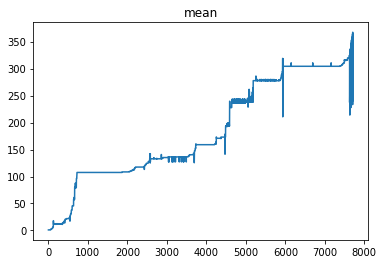

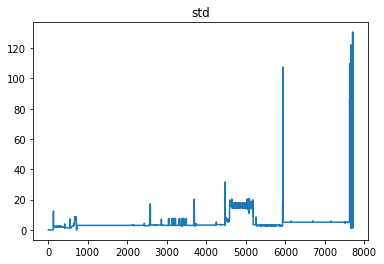

In [96]:
plt.plot([value[0] for value in rn2fo_aveNONE.values()])
plt.title('mean')
plt.show()

plt.plot([value[1] for value in rn2fo_aveNONE.values()])
plt.title('std')
plt.show()

In [3]:
cpd_df = pd.read_csv('../cpds_folditer_optimal_1000runs.csv', index_col=0)

In [4]:
cpd2fo_aveNONE = {}
for index in cpd_df.index:
    cpd2fo_aveNONE[index] = [np.mean(cpd_df.loc[index]), np.std(cpd_df.loc[index])]

In [8]:
# dict2csv(cpd2fo_aveNONE, '../data/assets/cpd2fo_aveNONE.csv')

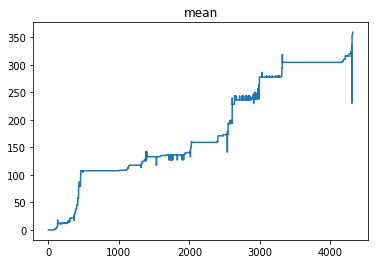

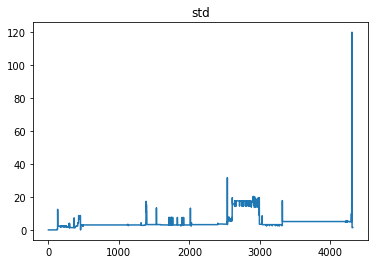

In [5]:
plt.plot([value[0] for value in cpd2fo_aveNONE.values()])
plt.title('mean')
plt.show()

plt.plot([value[1] for value in cpd2fo_aveNONE.values()])
plt.title('std')
plt.show()

In [100]:
x2rn['10']

['R02740',
 'R02739',
 'R06979',
 'R07364',
 'R02665',
 'R02535',
 'R02519',
 'R05986',
 'R07807',
 'R07497',
 'R07869',
 'R01819',
 'R02444',
 'R04276',
 'R07214',
 'R04872',
 'R05229',
 'R05301',
 'R05469',
 'R05468',
 'R05466',
 'R10415',
 'R10445',
 'R11065',
 'R06514',
 'R02777',
 'R06437',
 'R06424',
 'R08934',
 'R06433',
 'R11046',
 'R08597',
 'R10157',
 'R10145',
 'R00619',
 'R11210',
 'R03807',
 'R03009',
 'R03806',
 'R05097',
 'R06326',
 'R06336',
 'R06322',
 'R06323',
 'R06258',
 'R02422',
 'R00475',
 'R09402',
 'R09904',
 'R00522',
 'R10724',
 'R10784',
 'R12501',
 'R06344',
 'R06337',
 'R07053',
 'R00879',
 'R00031',
 'R10761',
 'R05126',
 'R03921',
 'R10741',
 'R05554',
 'R12216',
 'R05285',
 'R01098',
 'R11340',
 'R04383',
 'R06628',
 'R07997',
 'R02397',
 'R03590',
 'R05624',
 'R05493',
 'R05036',
 'R07657',
 'R10766',
 'R01898',
 'R05127',
 'R05037',
 'R07993',
 'R06345',
 'R05198',
 'R07864',
 'R08182',
 'R08008',
 'R06551',
 'R08081',
 'R05062',
 'R03008',
 'R08009',

In [101]:
cpd2fo_aveNONE['C00017']

[277.615, 3.1913594282061055]

## cpd2fo_64

In [56]:
cpd_df = pd.read_csv('pro_pero/pro_pero_cpds_folditer.csv', index_col=0)

In [57]:
cpd2fo_ave64 = {}
for index in cpd_df.index:
    cpd2fo_ave64[index] = [np.mean(cpd_df.loc[index]), np.std(cpd_df.loc[index])]

In [59]:
# dict2csv(cpd2fo_ave64, '../data/assets/cpd2fo_ave64.csv')

# X558

In [102]:
getXinfo('558')
getXinfo2('558')

X558 |ds_a/b/e= 0.0 0.0 0.91 |fo=239.1 |ns=4315 |#rn=1 |grp2 |aux |Xname=N/A |e_only
      |map00565: Ether lipid metabolism|O2=0:0/1 |alpha duplicates or obligate multimers


In [103]:
x2rn['558']

['R04452']

In [104]:
rn2rules['R04452'], rn2eqn_SI['R04452'], rn2reversible['R04452']

({frozenset({'7579'}), frozenset({'2007', '5', '558'})},
 'C04317 + C00033 => C04598 + C00001',
 True)

In [105]:
x2foAveNONE['7579']

37.741

In [26]:
batm = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')

In [108]:
batm.rns_folditer['R04452']

170

In [ ]:
for c in ['C04317', 'C00033', 'C04598']:
    print(batm.cpds_folditer[c], c, cpd2name[c])

In [ ]:
for rn in cpd2rn['C22173']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

In [ ]:
for rn in cpd2rn['C05102']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

In [ ]:
for rn in cpd2rn['C19861']:
    print(rn, rn2eqn_SI[rn], rn2reversible[rn])

# Alkane C01371

In [133]:
cpd2fo_aveNONE['C01371']

[170.833, 3.5834495950131626]

In [134]:
for rn in cpd2rn['C01371']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

N R00052_v1 2C00001 + C01334 + Z00025 => C00027 + C01371 + C01327 + Z00025 False
N R00052_v2 2C00001 + C01334 + Z00062 => C00027 + C01371 + C01327 + Z00062 False
N R02281_v1 2C00340 + 2C00080 + C01371 + C00007 + Z00025 + Z00015 => 2C00435 + C00226 + C00001 + Z00025 + Z00015 False
N R03529 C01371 + C00703 => C01343 + C00080 True
170 R09466_v1 C01371 + C00237 + Z00015 + Z00016 => C00609 + Z00015 + Z00016 True
N R09505_v1 2C00001 + C00720 + Z00062 => C01371 + C13645 + C00027 + Z00062 False
170 R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True


In [135]:
# alkylmercury <-> alkane; not in original run; only one reaction
'C01343' in batm.cpds_folditer.keys(), cpd2name['C01343'], cpd2rn['C01343']

(False, 'Alkylmercury', ['R03529'])

In [136]:
for c in ['C00609']:
    print(c, cpd2name[c], batm.cpds_folditer[c])

C00609 Long-chain aldehyde 170


In [137]:
for rn in cpd2rn['C00609']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R02039 C00347 + C00004 + C00080 => C00609 + C00003 + C00001 True
N R02620 C02843 + C00005 + C00080 => C00609 + C00010 + C00006 False
170 R09466_v1 C01371 + C00237 + Z00015 + Z00016 => C00609 + Z00015 + Z00016 True
275 R09484_v1 C20683 + C00004 + C00080 + Z00029 => C00609 + C00229 + C00003 + Z00029 True
275 R09484_v2 C20683 + C00004 + C00080 + Z00069 => C00609 + C00229 + C00003 + Z00069 True
275 R09485_v1 C20683 + C00005 + C00080 + Z00029 => C00609 + C00229 + C00006 + Z00029 True
275 R09485_v2 C20683 + C00005 + C00080 + Z00069 => C00609 + C00229 + C00006 + Z00069 True
N R10549 C03371 + C00005 + C00080 => C00609 + C02743 + C00006 True
306 R10551 C00609 + C01847 + C00007 => C00638 + C00205 + C00061 + C00001 False


In [19]:
rn2cpd_SI = csv2dict('../data/assets/rn2cpds_SI.csv')

In [139]:
for c in ['C00347']:
    print(c, cpd2name[c], batm.cpds_folditer[c])

C00347 Long-chain carboxylate 170


In [140]:
for rn in cpd2rn['C00347']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R01998 2C00004 + 2C00080 + C00347 => 2C00003 + C00339 + C00001 True
170 R02039 C00347 + C00004 + C00080 => C00609 + C00003 + C00001 True
170 R02040 C00347 + C00025 => C04305 + C00001 False
170 R02041 C00347 + C00189 => C04080 + C00001 False
N R02042 C01629 + C00001 => C00339 + C00347 False


In [141]:
for c in ['C00339']:
    print(c, cpd2name[c], batm.cpds_folditer[c])

C00339 Long-chain alcohol 170


In [142]:
for rn in cpd2rn['C00339']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R01998 2C00004 + 2C00080 + C00347 => 2C00003 + C00339 + C00001 True
N R01999 C00010 + C02434 => C00040 + C00339 False
N R02042 C01629 + C00001 => C00339 + C00347 False
170 R04311_v1 C03715 + C03129 + Z00013 => C03372 + C00339 + Z00013 True
N R10104 2C00005 + 2C00080 + C02843 => 2C00006 + C00339 + C00010 False


In [143]:
for c in ['C03715', 'C03129']:
    print(c, cpd2name[c], batm.cpds_folditer[c])

C03715 O-Alkylglycerone phosphate 170
C03129 Long-chain acid anion 170


In [144]:
for rn in cpd2rn['C03129']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R04311_v1 C03715 + C03129 + Z00013 => C03372 + C00339 + Z00013 True


In [145]:
for rn in cpd2rn['C03715']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R03944 C00008 + C03715 => C00002 + C02446 True
170 R04311_v1 C03715 + C03129 + Z00013 => C03372 + C00339 + Z00013 True
170 R04360 C03715 + C00005 + C00080 => C03968 + C00006 True


In [146]:
for c in ['C03968', 'C02446', 'C03372']:
    print(c, cpd2name[c], batm.cpds_folditer[c])

C03968 1-Alkyl-sn-glycero-3-phosphate 170
C02446 O-Alkylglycerone 170
C03372 Acylglycerone phosphate 107


In [147]:
for rn in cpd2rn['C03968']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

170 R03455 C00024 + C03968 => C00010 + C01264 False
170 R04126 C00008 + C03968 => C00002 + C02773 True
170 R04360 C03715 + C00005 + C00080 => C03968 + C00006 True
N R04361 C00010 + C05977 => C00040 + C03968 False
170 R04362_v1 C03968 + C00189 + Z00055 + Z00054 => C04476 + C00001 + Z00055 + Z00054 False


# Alkene C01372

In [ ]:
batm.cpds_folditer['C01372'], cpd2name['C01372']

In [ ]:
for rn in cpd2rn['C01372']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])
    print(f'   {rn2rules[rn]}')

In [ ]:
batm.folds_folditer['7579']

In [ ]:
# alkene is made from 'C21657'
batm.cpds_folditer['C21657'], cpd2name['C21657']

In [ ]:
# 

In [ ]:
cpd2name['C00722']

In [ ]:
for rn in cpd2rn['C00722']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])
    print(f'   {rn2rules[rn]}')

# TODO

In [ ]:
### curious

: 355 LUCA proteins

In [ ]:
### LongoLab

: thermo: H2O2 (ad hoc fix)  <= learn how to build/modify metabolism
: gate Oxygen by X5037? (or not)
    
: mean hydrophobicity vs. fold order
    - xgroup2hydrophobicity
    - one representative sequence => per-residue hydrophobicity
    - multiple representative sequences => take average
    : average over 1000 runs
        
: read PLOS: Exploring Fold Space Preferences of New-born and Ancient Protein Superfamilies

# folds injected early in 'after'

In [116]:
rn2cpd_SI = csv2dict('../data/assets/rn2cpds_SI.csv')

In [111]:
for x in ['3156', '132', '911']:
    getXinfo(x)
    getXinfo2(x)

X3156 |ds_a/b/e= 0.36 0.48 0.83 |fo=281.3 |ns=4311 |#rn=44 |grp2 |indep |Xname=Cupredoxin-like
      |M00154: Cytochrome c oxidase |O2=9:0/20 |beta sandwiches
X132 |ds_a/b/e= 0.0 0.05 0.35 |fo=318.7 |ns=4314 |#rn=38 |grp2 |indep |Xname=ACP-like
      |M00083: Fatty acid biosynthesis, elongation |O2=0:0/15 |alpha bundles
X911 |ds_a/b/e= 0.19 0.18 0.18 |fo=319.0 |ns=4315 |#rn=2 |grp2 |indep |Xname=N/A |forgotten
      |no module, no map                                                |O2=0:0/1 |few secondary structure elements


In [125]:
for rn in x2rn['911']:
    print(rn, rn2eqn_SI.get(rn, 'N/A'), rn2reversible.get(rn, 'N'))

R09502 N/A N
R09502_v1 2C00139 + 2C00080 + C00342 + Z00002 => 2C00138 + C00343 + Z00002 True


In [122]:
for c in rn2cpd_SI['R09502_v1']:
    print(c[-6:], cpd2name[c[-6:]], batm.cpds_folditer.get(c[-6:], 'N'))

C00342 Thioredoxin 275
C00138 Reduced ferredoxin 45
C00139 Oxidized ferredoxin 45
C00080 H+ 0
C00343 Thioredoxin disulfide 275
Z00002 4Fe4S 0


In [126]:
for rn in x2rn['3156']:
    print(rn, rn2eqn_SI.get(rn, 'N/A'), rn2reversible.get(rn, 'N'))

R02804 N/A N
R00783 N/A N
R00785 N/A N
R09492 N/A N
R00068 N/A N
R02394 N/A N
R00074 N/A N
R00078 N/A N
R00081 N/A N
R11335 N/A N
R00083 N/A N
R08762 N/A N
R11881 N/A N
R11882 N/A N
R11880 N/A N
R00280 N/A N
R00784 N/A N
R00082 N/A N
R02621 N/A N
R10444 N/A N
azurin_syn1 C00017 + Z00070 => C05357 False
azurin_syn2 C00017 + Z00070 => C05358 False
R00783_v2 C00088 + C00126 + C00080 + Z00025 + Z00010 => C00533 + C00001 + C00125 + Z00025 + Z00010 True
R00280_v1 2C00088 + C00030 + Z00070 => 2C00533 + 2C00001 + C00028 + Z00070 True
R00074_v1 4C01987 + 3C00007 + Z00030 + Z00019 + Z00013 => 2C02161 + 6C00001 + Z00030 + Z00019 + Z00013 False
R02394_v1 2C00486 + C00007 + Z00070 => 2C00500 + 2C00001 + Z00070 False
R08762_v2 2C01987 + C00007 + Z00070 + Z00019 => 2C17500 + 2C00001 + Z00070 + Z00019 False
R00784_v1 C00088 + C01000 + C00080 + Z00070 => C00533 + C00001 + C00997 + Z00070 True
R02621_v1 C03022 + C00014 + Z00055 => C00613 + C00001 + Z00055 False
R00784_v2 C00088 + C01000 + C00080 + Z0002

In [128]:
cpd2name['C03688']

'Apo-[acyl-carrier protein]'

In [127]:
for rn in x2rn['132']:
    print(rn, rn2eqn_SI.get(rn, 'N/A'), rn2reversible.get(rn, 'N'))

R04952 N/A N
R04536 N/A N
R04534 N/A N
R04533 N/A N
R04355 N/A N
R04543 N/A N
R04566 N/A N
R04964 N/A N
R04963 N/A N
R04968 N/A N
R04960 N/A N
R04953 N/A N
R04957 N/A N
R04726 N/A N
R05190 N/A N
ACP_syn N/A N
RZ_517 C00017 => C03688 False
R04963_v1 C05756 + C00011 + C00229 + Z00038 + C05756 + C00011 + C00229 + Z00038 + C05756 + C00011 + C00229 + Z00038 + Z00014 => C05755 + C01209 + Z00038 + C05755 + C01209 + Z00038 + C05755 + C01209 + Z00038 + Z00014 True
R04536_v1 C05750 + C00005 + C00080 + Z00038 + C05750 + C00005 + C00080 + Z00051 + C05750 + C00005 + C00080 + Z00038 + Z00014 => C04620 + C00006 + Z00038 + C04620 + C00006 + Z00051 + C04620 + C00006 + Z00038 + Z00014 True
R04960_v1 C05753 + C00011 + C00229 + Z00038 + C05753 + C00011 + C00229 + Z00038 + C05753 + C00011 + C00229 + Z00038 + Z00014 => C05752 + C01209 + Z00038 + C05752 + C01209 + Z00038 + C05752 + C01209 + Z00038 + Z00014 True
R04534_v2 C05753 + C00005 + Z00003 => C04619 + C00006 + Z00003 True
R04534_v1 C05753 + C00005 + Z0

In [129]:
for rn in x2rn['2492']:
    print(rn, rn2eqn_SI.get(rn, 'N/A'), rn2reversible.get(rn, 'N'))

R04549 N/A N
R04606 C00015 + C04932 => C04652 + C04824 True
R03459 N/A N
R03458 C01268 + C00005 + C00080 => C04454 + C00006 True
R09377 C04454 + C00014 => C18910 + C00001 False
R01127 C04734 => C00130 + C00001 True
R04325 C00101 + C04376 => C00234 + C03838 True
R04560 C00101 + C04734 => C00234 + C04677 True
R10231 N/A N
R01004 C00621 + C00001 => C00110 + C00009 False
R08221 N/A N
R01878 N/A N
R11524 N/A N
R01676 N/A N
R01663 N/A N
R10223 N/A N
R00974 N/A N
R01411 N/A N
R02485 N/A N
R02922 C02565 + C00014 => C00791 + C00001 True
R04326 C04376 + C00101 => C03838 + C00445 + C00001 True
R02418 C04090 + C00001 => C00496 + C00145 False
R00974_v1 C00380 + C00001 + Z00054 => C00106 + C00014 + Z00054 False
R11524_v1 C00097 + C15810 + Z00054 => C21437 + C00001 + Z00054 False
R01411_v1 C00178 + C00014 + Z00054 => C02376 + C00001 + Z00054 True
R01663_v1 C00365 + C00014 + Z00054 => C00239 + C00001 + Z00054 True
R08221_v1 C12739 + C00014 + Z00054 => C16635 + C00001 + Z00054 True
R10231_v1 C20458 + C

In [131]:
getXinfo('3294')
getXinfo2('3294')

X3294 |ds_a/b/e= 0.0 0.0 0.16 |fo=319.7 |ns=4315 |#rn=36 |grp2 |aux |Xname=N/A
      |M00083: Fatty acid biosynthesis, elongation |O2=0:0/15 |alpha complex topology


In [132]:
rn2rules.keys()

dict_keys(['R01015', 'R01061', 'R01063', 'R00200', 'R04779', 'R00658', 'R01070', 'R01786', 'R02740', 'R07159', 'R09084', 'R02189', 'R09085', 'R01512', 'R01518', 'R00431', 'R00726', 'R00341', 'R04780', 'R01827', 'R01641', 'R02739', 'R02736', 'R10907', 'R01056', 'R01830', 'R10221', 'R01529', 'R01528', 'R02035', 'R01049', 'R05605', 'R00709', 'R01900', 'R01325', 'R00268', 'R00267', 'R01324', 'R00351', 'R01899', 'R00472', 'R00342', 'R10612', 'R00473', 'R00479', 'R00705', 'R03045', 'R04432', 'R03158', 'R01608', 'R00706', 'R12356', 'R01383', 'R01896', 'R00286', 'R01476', 'R02640', 'R01481', 'R01639', 'R01478', 'R01904', 'R01381', 'R03313', 'R01251', 'R00239', 'R02291', 'R00480', 'R10147', 'R04475', 'R02734', 'R04199', 'R00451', 'R04365', 'R02735', 'R04198', 'R01773', 'R04405', 'R00946', 'R01286', 'R01775', 'R03260', 'R01777', 'R01466', 'R01771', 'R04173', 'R01513', 'R00582', 'R00586', 'R00897', 'R02412', 'R02413', 'R03460', 'R03083', 'R03084', 'R01826', 'R01714', 'R01373', 'R01715', 'R00694',

# 3 cpds that re-appear (but not really) in LOO

In [36]:
len(rn2cpd_SI)

12277

In [32]:
# these cpds do not appear in any reactions from SI

for rn, cpds in rn2cpd_SI.items():
    if set(['C00034', 'Z00020', 'C00050']) & set(cpds) != set():
        print(rn, cpds)

In [42]:
# stoichiometry fix
rn2cpd_SI_s = {}
for rn, cpds in rn2cpd_SI.items():
    new_cpds = []
    for c in cpds:
        new_cpds.append(c[-6:])
    rn2cpd_SI_s[rn] = new_cpds

In [39]:
seed80 = {'C00048', 'C00058', 'Z00064', 'C00175', 'Z00055', 'C00042', 'C00161', 'C00122', 'Z00053', 'Z00067', 'Z00069', 'Z00063', 'C00050', 'C00011', 'Z00001', 'C00209', 'Z00070', 'C00033', 'C00148', 'Z00030', 'Z00029', 'C00080', 'C19806', 'C00034', 'C00023', 'C00014', 'C00288', 'C01127', 'C00037', 'C01732', 'C00065', 'C00383', 'C00030', 'C06232', 'C00160', 'C00001', 'C17023', 'C00012', 'C00311', 'C00070', 'C00028', 'C00049', 'C00022', 'C00283', 'C14819', 'C00025', 'C01528', 'C00183', 'C00205', 'C00009', 'C01330', 'C20679', 'Z00015', 'C22155', 'C00123', 'Z00062', 'C00036', 'C00188', 'C19609', 'C14818', 'C00150', 'C00069', 'Z00054', 'C01335', 'C00282', 'Z00060', 'C00038', 'Z00033', 'Z00002', 'C00149', 'C00305', 'Z00020', 'C00041', 'C00071', 'C00238', 'C00407', 'Z00034', 'C00026', 'C00417', 'Z00006'}

In [40]:
len(seed80)

80

In [37]:
for c in seed80:
    print(c, cpd2name[c])

C00288 HCO3-
Z00015 Iron
Z00060 Monovalent Metal (M1)
C01528 Hydrogen selenide
Z00070 Copper
C00036 Oxaloacetate
Z00062 Vanadium
C00080 H+
Z00053 Tungsten
Z00002 4Fe4S
C00022 Pyruvate
Z00064 Molybdenum
Z00020 Generic FeS Cluster
Z00030 Mn
C00014 Ammonia
C00209 Oxalate
C00183 L-Valine
C00058 Formate
C01127 4-Hydroxy-2-oxoglutarate
C00149 (S)-Malate
C00026 2-Oxoglutarate
C00160 Glycolate
Z00069 Divalent Metal (M2)
C00188 L-Threonine
Z00054 Zinc
Z00063 Generic FeS
C06232 Molybdate
Z00006 Cobalt
C00148 L-Proline
C00070 Copper
C00049 L-Aspartate
C00161 2-Oxo acid
Z00029 Mg
C00238 Potassium cation
C01335 ROH
C00305 Magnesium cation
C00030 Reduced acceptor
C00205 hn
C00038 Zinc cation
C22155 [Fe-S] cluster scaffold protein
C00282 Hydrogen
C00407 L-Isoleucine
C01330 Sodium cation
C00041 L-Alanine
C00025 L-Glutamate
C00150 Molybdenum
C00042 Succinate
C19806 Propane-1,2,3-tricarboxylate
C20679 Tungstate
C00048 Glyoxylate
C00122 Fumarate
Z00067 3Fe4S
C14819 Fe3+
C00009 Orthophosphate
Z00033 Sodiu

In [47]:
seed80count = {key:0 for key in seed80}

for rn, cpds in rn2cpd_SI_s.items():
    for c in cpds:
        if c in seed80count.keys():
            seed80count[c] += 1

In [ ]:
missing = set(['C00034', 'C00050', 'Z00020'])

In [52]:
for c, count in seed80count.items():
    print(count, c, cpd2name[c])

32 C00288 HCO3-
605 Z00015 Iron
14 C00407 L-Isoleucine
14 Z00060 Monovalent Metal (M1)
9 C01528 Hydrogen selenide
107 Z00070 Copper
66 C00036 Oxaloacetate
5 C01330 Sodium cation
7 Z00062 Vanadium
2566 C00080 H+
15 Z00053 Tungsten
60 C00041 L-Alanine
210 Z00002 4Fe4S
223 C00025 L-Glutamate
1 C00150 Molybdenum
244 C00022 Pyruvate
179 C00042 Succinate
61 Z00064 Molybdenum
0 Z00020 Generic FeS Cluster
683 Z00030 Mn
482 C00014 Ammonia
1 C19806 Propane-1,2,3-tricarboxylate
3 C20679 Tungstate
78 C00048 Glyoxylate
12 C00209 Oxalate
21 C00122 Fumarate
18 Z00067 3Fe4S
6 C14819 Fe3+
11 C00183 L-Valine
95 C00058 Formate
815 C00009 Orthophosphate
12 Z00033 Sodium
2 C01127 4-Hydroxy-2-oxoglutarate
13 C17023 Sulfur donor
18 C00149 (S)-Malate
7 C00012 Peptide
295 C00026 2-Oxoglutarate
12 C00160 Glycolate
244 Z00069 Divalent Metal (M2)
0 C00034 Manganese
228 Z00055 Calcium
14 C00188 L-Threonine
476 Z00054 Zinc
220 Z00063 Generic FeS
775 C00011 CO2
53 C00283 Hydrogen sulfide
6 C06232 Molybdate
4 C00417 

In [55]:
cpd2name['C00030']

'Reduced acceptor'

In [ ]:
# 0 C00050 Metal
# 14 Z00060 Monovalent Metal (M1)
# 244 Z00069 Divalent Metal (M2)

# 0 C00034 Manganese
# 683 Z00030 Mn

# 0 Z00020 Generic FeS Cluster
# 220 Z00063 Generic FeS
# 119 Z00001 2Fe2S
# 210 Z00002 4Fe4S
# 3 C22155 [Fe-S] cluster scaffold protein
# 18 Z00067 3Fe4S